<font color="blue"><b>Inbroduction</b></font>

In [42]:
!pip install factor_analyzer

In [43]:
import pandas as pd
import numpy as np
from google.colab import files
import datetime as dt
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import shapiro, jarque_bera
from matplotlib.patches import Ellipse, Arc
import sympy as sp
import datetime as dt
import pandas_datareader.data as web
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer
from scipy.stats import lognorm
import math
import random

In [44]:
df = pd.read_csv("/content/drive/MyDrive/Quant/sp500.csv")

In [45]:
df.head()

,Date,Open,High,Low,Close
0,1975-09-15,83.300003,83.489998,82.290001,82.879997
1,1975-09-16,82.879997,83.430000,81.790001,82.089996
2,1975-09-17,82.089996,82.930000,81.570000,82.370003
3,1975-09-18,82.370003,84.339996,82.230003,84.059998
4,1975-09-19,84.260002,86.389999,84.260002,85.879997


In [46]:
# Make sure index is datetime
df.index = pd.to_datetime(df.index)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [47]:
# Filter the period
df_filtered = df.loc["1975-09-15":"2025-09-15"]

<font color="blue"><b>Ex. 1 (a)</b></font>


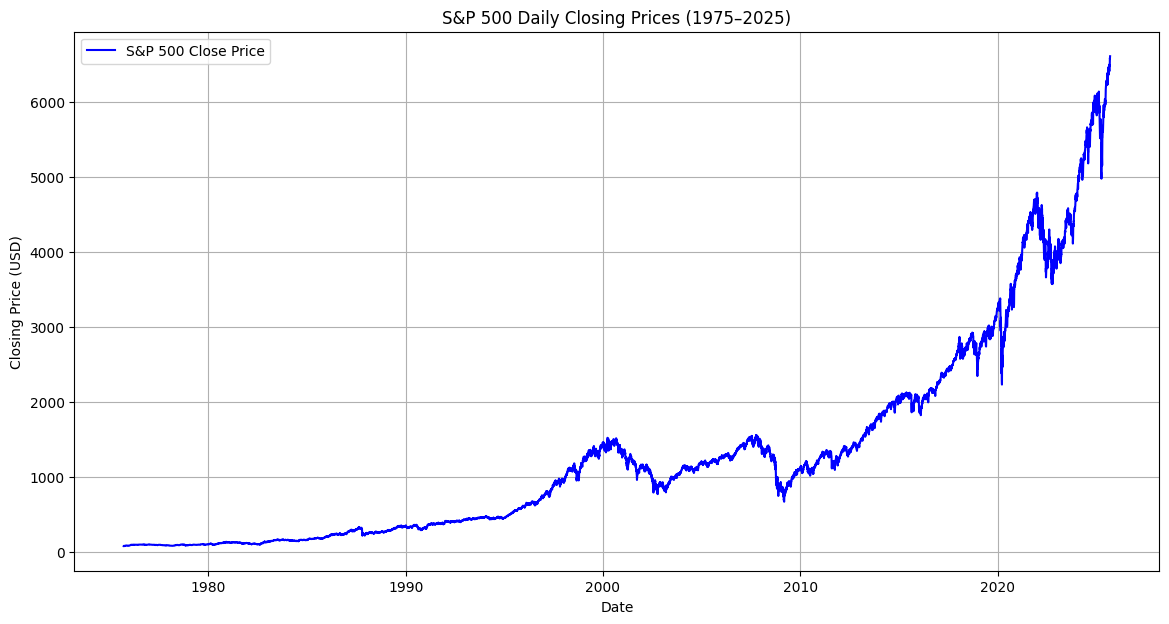

In [48]:
# Plot Close price
plt.figure(figsize=(14,7))
plt.plot(df_filtered.index, df_filtered['Close'], color="blue", label="S&P 500 Close Price")
plt.title("S&P 500 Daily Closing Prices (1975–2025)")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

<font color="blue"><b>Ex. 1 (b)</b></font>

**The daily return is calculated as:**

$$
R_t = (\frac{P_t - P_{t-1}}{P_{t-1}}) \times 100 = (\frac{P_t}{P_{t-1}} - 1) \times 100
$$

- $R_t$ = daily return at time $t$  
- $P_t$ = closing price today  
- $P_{t-1}$ = closing price yesterday

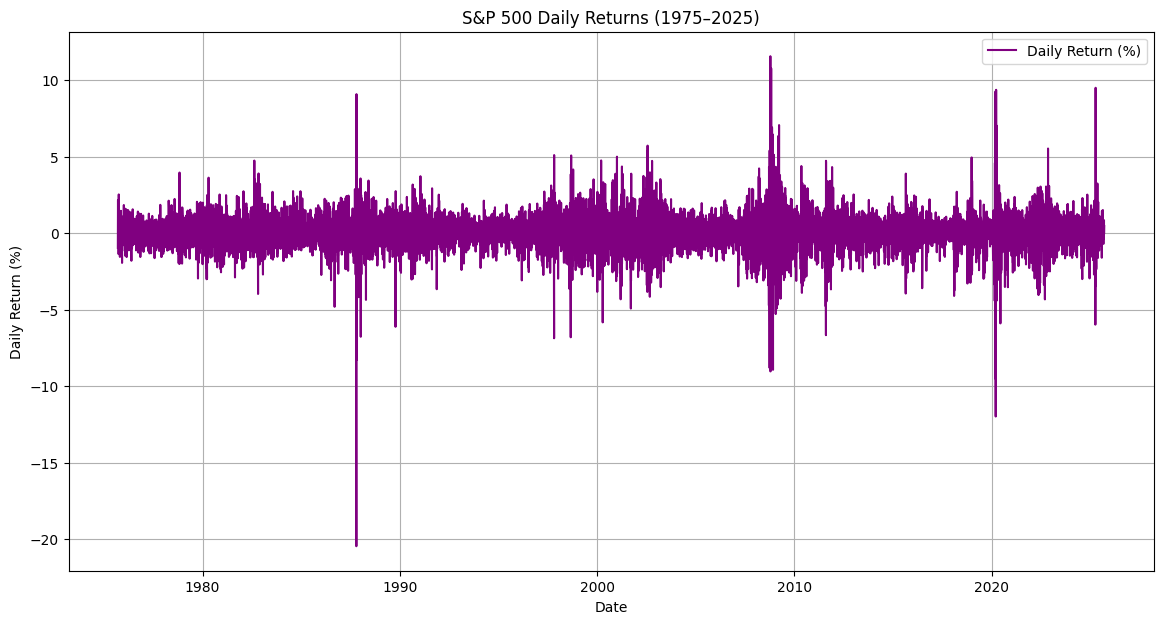

In [49]:
# Daily return = percentage change of Close
df['Daily Return'] = df['Close'].pct_change() * 100   # in %
plt.figure(figsize=(14,7))
plt.plot(df.index, df['Daily Return'], color="purple", label="Daily Return (%)")
plt.title("S&P 500 Daily Returns (1975–2025)")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.legend()
plt.grid(True)
plt.show()

<font color="blue"><b>Ex. 1 (c)</b></font>


> **As a rule of thumb**, the more that the points in a Q-Q plot lie on a straight diagonal line, the more normally distributed the data. **Conversely**, the more that the points deviate from a straight diagonal line, the less normally distributed the data.

The S&P 500 daily returns do not follow  a normal distribution. As points deviate strongly from the line in the tails. This means there are more extreme returns (fat tails) than a normal distribution would predict.






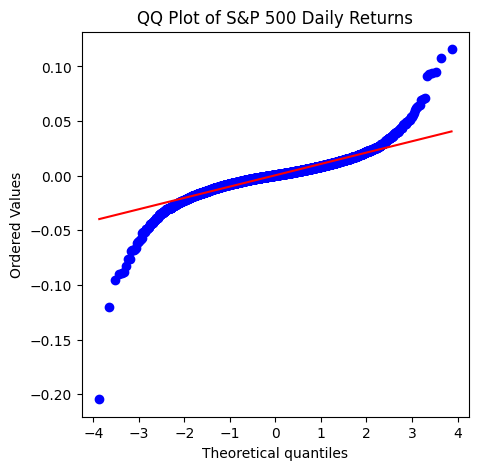

In [50]:
# Calculate daily returns
df['Daily Return'] = df['Close'].pct_change()
returns = df['Daily Return'].dropna()

# QQ Plot
plt.figure(figsize=(5,5))
stats.probplot(returns, dist="norm", plot=plt)
plt.title("QQ Plot of S&P 500 Daily Returns")
plt.show()



> To formally test the normality of the S&P 500 daily return series, we can apply two statistical tests:

**Shapiro–Wilk Test** and **Jarque–Bera Test**.



**Shapiro–Wilk Test**

The Shapiro–Wilk test evaluates the null hypothesis that a sample $(x_1, x_2, \dots, x_n)$ came from a normally distributed population. For more details: [[Shapiro–Wilk test]](https://en.wikipedia.org/wiki/Shapiro%E2%80%93Wilk_test)

**The test statistic is defined as:**
$$
W = \frac{\left( \sum_{i=1}^{n} a_i x_{(i)} \right)^2}{\sum_{i=1}^{n} \left( x_i - \overline{x} \right)^2}
$$
**where:**
- $x_{(i)}$ are the **ordered sample values** (from smallest to largest),  
- $\overline{x}$ is the **sample mean**,  
- $a_i$ are constants derived from the expected values of the order statistics of a normally distributed sample.  

If the p-value associated with W is less than 0.05, we reject the null hypothesis and conclude that the data is **not normally distributed**.


**Results:**
- Test statistic =  **0.8951544995780921**
- p-value ≈ **5.018566335926154e-68**

- Since the p-value is far **smaller than 0.05**, we reject the null hypothesis $H_0$ that the returns are normally distributed.  
- **Interpretation:** the return series deviates significantly from a normal distribution.

In [51]:
# Shapiro–Wilk Test
shapiro_test = shapiro(returns)
print("Shapiro-Wilk Test:")
print("Statistic =", shapiro_test.statistic, ", p-value =", shapiro_test.pvalue)


Shapiro-Wilk Test:
Statistic = 0.8951544995780921 , p-value = 5.018566335926154e-68


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12605.
  res = hypotest_fun_out(*samples, **kwds)


**Jarque–Bera Test**
In statistics, the **Jarque–Bera test** is a goodness-of-fit test of whether sample data have the skewness and kurtosis matching a normal distribution. The test statistic is always nonnegative. If it is far from zero, it signals the data does not have a normal distribution. For more details: [[Jarque–Bera test]](https://en.wikipedia.org/wiki/Jarque%E2%80%93Bera_test)

**The test statistic is defined as:**
$$
JB = \frac{n}{6} \left( S^2 + \frac{1}{4}(K - 3)^2 \right)
$$
**Where:**
- n = sample size  
- S = sample skewness  
- K = sample kurtosis  

**For a perfectly normal distribution:**
- S = 0 (no skewness)  
- K = 3 (mesokurtic distribution)  
If the **p-value smaller than 0.05**, we reject the null hypothesis $H_0$ and conclude that the data is **not normally distributed**.

**Results (Jarque–Bera Test):**
- Test statistic = **202218.7448978875**  
- p-value = **0.0**  

- Since the p-value is far **smaller than 0.05**, we reject the null hypothesis $H_0$ that the returns are normally distributed.  
- **Interpretation:** the return series exhibits **fat tails** (excess kurtosis) and **skewness**, deviating strongly from a normal distribution.

In [52]:
# Jarque–Bera Test
jb_test = jarque_bera(returns)
print("\nJarque-Bera Test:")
print("Statistic =", jb_test.statistic, ", p-value =", jb_test.pvalue)


Jarque-Bera Test:
Statistic = 202218.7448978875 , p-value = 0.0


<font color="blue"><b>Ex. 1 (d)</b></font>


**Annualized Return:**

$$
R_{annual} = R_{daily} \times 250
$$

**Annualized Volatility:**

$$
\sigma_{annual} = \sigma_{daily} \times \sqrt{250}
$$

In [53]:
# Split into periods
before_2000 = df.loc[:'1999-12-31']['Daily Return'].dropna()
after_2000 = df.loc['2000-01-01':]['Daily Return'].dropna()
whole_period = df['Daily Return'].dropna()

# Calculate mean and std
results = pd.DataFrame({
    'Average Daily Return (%)': [
        whole_period.mean() * 100,
        before_2000.mean() * 100,
        after_2000.mean() * 100
    ],
    'Daily Std. Deviation (%)': [
        whole_period.std() * 100,
        before_2000.std() * 100,
        after_2000.std() * 100
    ]
}, index=['Whole Period', 'Before 2000', 'After 2000'])

results

,Average Daily Return (%),Daily Std. Deviation (%)
Whole Period,0.040803,1.096984
Before 2000,0.051348,0.944628
After 2000,0.030785,1.224279


<font color="blue"><b>Ex. 1 (e)</b></font>

**Comparison and Comments:**
- The **whole period** shows about **10.2% annualized return** with volatility around **17.3%**.  
- **Before 2000**: higher return (**12.8%**) and lower volatility (**14.9%**). As a consequence, a more favorable risk-return tradeoff.  
- **After 2000**: lower return (**7.7%**) and higher volatility (**19.4%**). As a consequence, markets became riskier and less rewarding.  
- This reflects major crises after 2000 (dot-com bubble, 2008 financial crisis, COVID-19 crash, Russian-Ukranian conflict, etc.).  
- Overall, the S&P 500 provides positive long-term returns, but volatility is much larger than the mean return, consistent with the high-risk nature of equities.

In [54]:
# Helper function to compute annualized return & volatility
def annualize_stats(daily_returns):
    avg_daily = daily_returns.mean()
    std_daily = daily_returns.std()

    avg_annual = avg_daily * 250
    std_annual = std_daily * np.sqrt(250)

    return avg_daily*100, std_daily*100, avg_annual*100, std_annual*100

# Whole, before 2000, after 2000
whole = df['Daily Return'].dropna()
before_2000 = df.loc[:'1999-12-31']['Daily Return'].dropna()
after_2000 = df.loc['2000-01-01':]['Daily Return'].dropna()

# Build results table
results_annualized = pd.DataFrame(
    [annualize_stats(whole),
     annualize_stats(before_2000),
     annualize_stats(after_2000)],
    columns=[
        'Avg Daily Return (%)',
        'Daily Std Dev (%)',
        'Annualized Return (%)',
        'Annualized Std Dev (%)'
    ],
    index=['Whole Period','Before 2000','After 2000']
)

results_annualized

,Avg Daily Return (%),Daily Std Dev (%),Annualized Return (%),Annualized Std Dev (%)
Whole Period,0.040803,1.096984,10.200775,17.344836
Before 2000,0.051348,0.944628,12.837006,14.935874
After 2000,0.030785,1.224279,7.696274,19.357557


<font color="blue"><b>Ex. 1 (f)</b></font>

**Conclusion:**
- At the **5% level**, the data behaves fairly close to normal.  
- At the **1% level**, we observe **far more extreme events** than predicted by the normal distribution.  
- This confirms the presence of **fat tails** in financial returns: large crashes and rallies occur more frequently than Gaussian theory suggests.

In [55]:
# Daily returns (drop missing values)
returns = df['Daily Return'].dropna()

# Sample mean & std
mu = returns.mean()
sigma = returns.std()

# Thresholds under normality
z_5 = 1.96   # ~5% two-tailed
z_1 = 2.58   # ~1% two-tailed

thr_5_upper = mu + z_5 * sigma
thr_5_lower = mu - z_5 * sigma

thr_1_upper = mu + z_1 * sigma
thr_1_lower = mu - z_1 * sigma

# Actual counts
n_total = len(returns)
outside_5 = np.sum((returns < thr_5_lower) | (returns > thr_5_upper))
outside_1 = np.sum((returns < thr_1_lower) | (returns > thr_1_upper))

# Percentages
perc_5 = outside_5 / n_total * 100
perc_1 = outside_1 / n_total * 100

print("5% tails:")
print("Expected ≈ 5%, Actual ≈", perc_5, "%, Count =", outside_5)

print("\n1% tails:")
print("Expected ≈ 1%, Actual ≈", perc_1, "%, Count =", outside_1)

5% tails:
Expected ≈ 5%, Actual ≈ 4.88694962316541 %, Count = 616

1% tails:
Expected ≈ 1%, Actual ≈ 2.2292740975803254 %, Count = 281


<font color="blue"><b>Ex. 2 (a)</b></font>



> We are asked to compute the variance of: $P = 0.5X + 0.3Y + 0.2Z$

For any linear combination of random variables:
$
\operatorname{Var}(aX+bY+cZ) = a^2\operatorname{Var}(X) + b^2\operatorname{Var}(Y) + c^2\operatorname{Var}(Z)
+ 2ab\,\operatorname{Cov}(X,Y) + 2ac\,\operatorname{Cov}(X,Z) + 2bc\,\operatorname{Cov}(Y,Z)
$
$\operatorname{Var}(X) = \operatorname{Var}(Y) = \operatorname{Var}(Z) = 1$  
$\operatorname{Cov}(X,Y) = 0.8$  
$\operatorname{Cov}(X,Z) = 0.8$  
$\operatorname{Cov}(Y,Z) = \rho$  
$
\operatorname{Var}(P) = (0.5)^2 + (0.3)^2 + (0.2)^2
+ 2(0.5)(0.3)(0.8) + 2(0.5)(0.2)(0.8) + 2(0.3)(0.2)\rho
$
$
\operatorname{Var}(P) = 0.38 + 0.24 + 0.16 + 0.12\rho
$\
$
\operatorname{Var}(P) = 0.78 + 0.12\rho
$



In [56]:
# Define symbols
rho = sp.symbols('rho')
a, b, c = 0.5, 0.3, 0.2

# Variances
Var_X = Var_Y = Var_Z = 1
Cov_XY = 0.8
Cov_XZ = 0.8
Cov_YZ = rho

# Formula for Var(P)
Var_P = (a**2 * Var_X) + (b**2 * Var_Y) + (c**2 * Var_Z) \
        + 2*a*b*Cov_XY + 2*a*c*Cov_XZ + 2*b*c*Cov_YZ

# Simplify expression
Var_P_simplified = sp.simplify(Var_P)
Var_P_simplified

0.12*rho + 0.78

<font color="blue"><b>Ex. 2 (b)</b></font>

For any weight vector $W = (w_x, w_y, w_z)$, the variance is defined as the expected squared deviation and can never be negative.

- If the correlation matrix $\Sigma$ is **positive definite**, then for all nonzero $W$:  
  $\operatorname{Var}(P) > 0$.

- If the correlation matrix $\Sigma$ is only **positive semidefinite**, then for some special $W$ the variance may equal $0$ (degenerate case).

The variance of $P$ is always non-negative. It is strictly positive for all nonzero weights if the correlation matrix is positive definite.






<font color="blue"><b>Ex. 2 (c)</b></font>

Let the weight vector be

$$
W = \begin{bmatrix} w_x \\ w_y \\ w_z \end{bmatrix},
$$

and the correlation matrix be

$$
\Sigma =
\begin{bmatrix}
1 & 0.8 & 0.8 \\
0.8 & 1 & \rho \\
0.8 & \rho & 1
\end{bmatrix}.
$$

Then the variance of $P = w_x X + w_y Y + w_z Z$ is

$$
\operatorname{Var}(P) = W^\top \Sigma W
$$

The Expression Form of P:

$$
\operatorname{Var}(P) = w_x^2 + w_y^2 + w_z^2
+ 2(0.8)\,w_x w_y + 2(0.8)\,w_x w_z + 2\rho\, w_y w_z
$$


<font color="blue"><b>Ex. 2 (d)</b></font>

For any weights $W$, the variance must satisfy:

$$
\operatorname{Var}(P) = W^\top \Sigma W \;\geq\; 0
$$

This condition means that the correlation matrix $\Sigma$ must be:

- **Symmetric**  
- **Positive semidefinite (PSD)**. So, all eigenvalues $\geq 0$ (so that $W^\top \Sigma W \geq 0$ for all $W$)  
- With $1$'s on the diagonal (since each variable has variance $1$)

The correlation matrix $\Sigma$ must be **positive semidefinite (PSD)**.

<font color="blue"><b>Ex. 2 (e)</b></font>

The correlation matrix is:

$$
\Sigma =
\begin{bmatrix}
1 & 0.8 & 0.8 \\
0.8 & 1 & \rho \\
0.8 & \rho & 1
\end{bmatrix}
$$

For
$$
A=
\begin{bmatrix}
a & b & c\\
d & e & f\\
g & h & i
\end{bmatrix},
\quad
\det(A)=a(ei - fh) - b(di - fg) + c(dh - eg).
$$

Here
$$
\Sigma =
\begin{bmatrix}
1 & 0.8 & 0.8 \\
0.8 & 1 & \rho \\
0.8 & \rho & 1
\end{bmatrix}.
$$

Apply the formula
$$
\det(\Sigma)
= a(ei - fh) - b(di - fg) + c(dh - eg)
$$

1) First term:
$$
a(ei - fh) = 1 \cdot (1 \cdot 1 - \rho \cdot \rho) = 1 - \rho^2
$$

2) Second term:
$$
-\,b(di - fg) = -0.8(0.8 \cdot 1 - \rho \cdot 0.8)
= -0.8(0.8 - 0.8\rho)
= -0.64 + 0.64\rho
$$

3) Third term:
$$
+\,c(dh - eg) = 0.8(0.8 \cdot \rho - 1 \cdot 0.8)
= 0.8(0.8\rho - 0.8)
= 0.64\rho - 0.64
$$

Combine and simplify
$$
\det(\Sigma) = (1 - \rho^2) + (-0.64 + 0.64\rho) + (0.64\rho - 0.64)
$$

$$
= 1 - \rho^2 - 1.28 + 1.28\rho
$$

$$
= -\rho^2 + 1.28\rho - 0.28
$$

$$
\det(\Sigma) = -\rho^2 + 1.28\rho - 0.28
$$


In [57]:
# Define the correlation matrix Σ
Sigma = sp.Matrix([
    [1, 0.8, 0.8],
    [0.8, 1, rho],
    [0.8, rho, 1]
])

# Show the matrix
print("Correlation matrix Σ:")
sp.pprint(Sigma)

# General formula for 3x3 determinant
# det(A) = a(ei - fh) - b(di - fg) + c(dh - eg)
a, b, c, d, e, f, g, h, i = sp.symbols('a b c d e f g h i')
det_formula = a*(e*i - f*h) - b*(d*i - f*g) + c*(d*h - e*g)
print("\nGeneral 3x3 determinant formula:")
sp.pprint(det_formula)

# Substitute values from Σ into the formula
subs_dict = {
    a: 1, b: 0.8, c: 0.8,
    d: 0.8, e: 1, f: rho,
    g: 0.8, h: rho, i: 1
}
det_Sigma_manual = det_formula.subs(subs_dict)
print("\nDeterminant:")
sp.pprint(sp.expand(det_Sigma_manual))

Correlation matrix Σ:
⎡ 1   0.8  0.8⎤
⎢             ⎥
⎢0.8   1    ρ ⎥
⎢             ⎥
⎣0.8   ρ    1 ⎦

General 3x3 determinant formula:
a⋅(e⋅i - f⋅h) - b⋅(d⋅i - f⋅g) + c⋅(d⋅h - e⋅g)

Determinant:
   2                
- ρ  + 1.28⋅ρ - 0.28


We found:
$$
\det(\Sigma) = -\rho^2 + 1.28\rho - 0.28 \;\;\geq\; 0
$$
Multiply by $-1$ (flip inequality)
$$
\rho^2 - 1.28\rho + 0.28 \;\leq\; 0
$$
Find the roots
$$
\rho = \frac{1.28 \pm \sqrt{1.28^2 - 4(0.28)}}{2}
$$
Simplify inside the square root
$$
= \frac{1.28 \pm \sqrt{1.6384 - 1.12}}{2}
= \frac{1.28 \pm \sqrt{0.5184}}{2}
$$
Evaluate
$$
= \frac{1.28 \pm 0.72}{2}
$$

So the two roots are:
$$
\rho = 0.28 \quad \text{and} \quad \rho = 1
$$
Since $\rho^2 - 1.28\rho + 0.28 \leq 0$, the solution lies **between the roots**:
$$
0.28 \leq \rho \leq 1
$$
The valid range of $\rho$ is
$$
[0.28, \; 1]
$$

Determinant of Σ: -rho**2 + 1.28*rho - 0.28
Valid range for rho: (0.28 <= rho) & (rho <= 1.0)
Roots of det(Σ)=0: [0.280000000000000, 1.00000000000000]
Numeric roots: [0.28, 1.0]


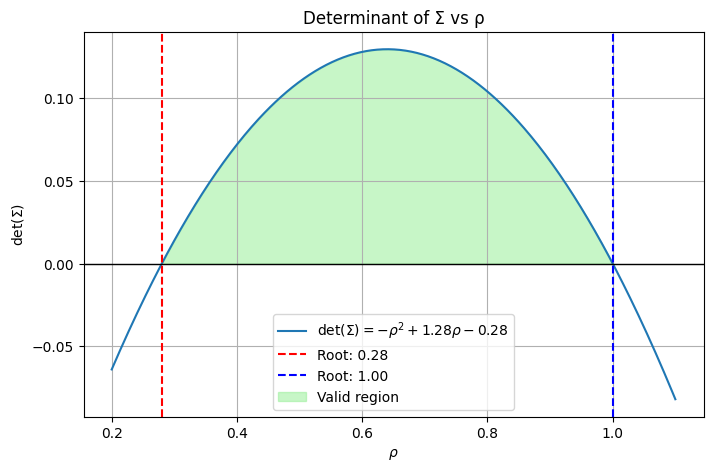

In [58]:
# Determinant expression
det_Sigma = -rho**2 + 1.28*rho - 0.28
print("Determinant of Σ:", det_Sigma)

# Solve inequality det(Σ) >= 0
solution = sp.solve_univariate_inequality(det_Sigma >= 0, rho)
print("Valid range for rho:", solution)

# Solve quadratic equation
roots = sp.solve(sp.Eq(det_Sigma, 0), rho)
print("Roots of det(Σ)=0:", roots)

# Numeric evaluation of roots
roots_eval = [float(r) for r in roots]
print("Numeric roots:", roots_eval)

# Plot det(Σ) over [0.28, 1]
rho_vals = np.linspace(0.2, 1.1, 400)
det_vals = [-r**2 + 1.28*r - 0.28 for r in rho_vals]

plt.figure(figsize=(8,5))
plt.plot(rho_vals, det_vals, label=r"$\det(\Sigma) = -\rho^2 + 1.28\rho - 0.28$")
plt.axhline(0, color="black", linewidth=1)
plt.axvline(roots_eval[0], color="red", linestyle="--", label=f"Root: {roots_eval[0]:.2f}")
plt.axvline(roots_eval[1], color="blue", linestyle="--", label=f"Root: {roots_eval[1]:.2f}")
plt.fill_between(rho_vals, det_vals, 0, where=(np.array(det_vals)>=0), color="lightgreen", alpha=0.5, label="Valid region")

plt.title("Determinant of Σ vs ρ")
plt.xlabel(r"$\rho$")
plt.ylabel(r"$\det(\Sigma)$")
plt.legend()
plt.grid(True)
plt.show()

<font color="blue"><b>Ex. 3 (a)</b></font>

We are given the covariance matrix:
$$
\Sigma =
\begin{bmatrix}
\sigma_1^2 & \rho \sigma_1 \sigma_2 \\
\rho \sigma_1 \sigma_2 & \sigma_2^2
\end{bmatrix}.
$$
Eigenvalues $\lambda$ satisfy:
$$
\det(\Sigma - \lambda I) = 0,
$$
$$
\det \begin{bmatrix}
\sigma_1^2 - \lambda & \rho \sigma_1 \sigma_2 \\
\rho \sigma_1 \sigma_2 & \sigma_2^2 - \lambda
\end{bmatrix} = 0.
$$
For a $2 \times 2$ matrix $\begin{bmatrix}a & b \\ c & d\end{bmatrix}$, we have $\det = ad - bc$.
So:
$$
\det(\Sigma - \lambda I)
= (\sigma_1^2 - \lambda)(\sigma_2^2 - \lambda) - (\rho \sigma_1 \sigma_2)^2.
$$
Expand $(\sigma_1^2 - \lambda)(\sigma_2^2 - \lambda)$:
$$
(\sigma_1^2 - \lambda)(\sigma_2^2 - \lambda)
= \sigma_1^2 \sigma_2^2 - \sigma_1^2 \lambda - \sigma_2^2 \lambda + \lambda^2.
$$
So:
$$
\det(\Sigma - \lambda I)
= \lambda^2 - (\sigma_1^2 + \sigma_2^2)\lambda + \sigma_1^2\sigma_2^2 - \rho^2\sigma_1^2\sigma_2^2.
$$
Simplify constant term:
$$
\det(\Sigma - \lambda I)
= \lambda^2 - (\sigma_1^2 + \sigma_2^2)\lambda + \sigma_1^2\sigma_2^2(1 - \rho^2).
$$
For quadratic $a\lambda^2 + b\lambda + c = 0$ with
- $a = 1$  
- $b = -(\sigma_1^2 + \sigma_2^2)$  
- $c = \sigma_1^2\sigma_2^2(1 - \rho^2)$

The discriminant is:
$$
\Delta = b^2 - 4ac
= (\sigma_1^2 + \sigma_2^2)^2 - 4\sigma_1^2\sigma_2^2(1 - \rho^2).
$$

Simplify:
$$
\Delta = (\sigma_1^2 - \sigma_2^2)^2 + 4\rho^2\sigma_1^2\sigma_2^2 \;\geq 0.
$$
Therefore:

$$
\lambda_{1,2} =
\frac{\sigma_1^2 + \sigma_2^2}{2}
\;\pm\;
\frac{1}{2}\sqrt{(\sigma_1^2 - \sigma_2^2)^2 + 4\rho^2\sigma_1^2\sigma_2^2},
$$

with $\lambda_1 \geq \lambda_2 \geq 0$.


In [59]:
# Symbols
s1, s2, r, lam = sp.symbols('s1 s2 r lam', real=True)

# Covariance matrix Σ
Sigma = sp.Matrix([[s1**2, r*s1*s2],
                   [r*s1*s2, s2**2]])
print("Covariance matrix Σ =")
display(Sigma)

# Eigenvalues (Sympy computes automatically)
eigvals = Sigma.eigenvals()   # dictionary {eigenvalue: multiplicity}
eigvals_list = list(eigvals.keys())

print("\nEigenvalues (symbolic):")
for ev in eigvals_list:
    display(ev)


Covariance matrix Σ =


Matrix([
[  s1**2, r*s1*s2],
[r*s1*s2,   s2**2]])


Eigenvalues (symbolic):


s1**2/2 + s2**2/2 - sqrt(4*r**2*s1**2*s2**2 + s1**4 - 2*s1**2*s2**2 + s2**4)/2

s1**2/2 + s2**2/2 + sqrt(4*r**2*s1**2*s2**2 + s1**4 - 2*s1**2*s2**2 + s2**4)/2

<font color="blue"><b>Ex. 3 (b)</b></font>

We now compute the eigenvectors $\gamma_1, \gamma_2$:

Assume $\gamma =
\begin{pmatrix}
v_1 \\
v_2
\end{pmatrix}$
such that:
$$
\Sigma \gamma = \lambda \gamma.
$$

This gives the system:
$$
(\sigma_1^2 - \lambda)v_1 + \rho\sigma_1\sigma_2 v_2 = 0,
$$
$$
\rho\sigma_1\sigma_2 v_1 + (\sigma_2^2 - \lambda)v_2 = 0.
$$

Because we have $\gamma_i' \gamma_i = 1$, we can express the eigenvector as  
$\gamma = \begin{pmatrix}\cos\phi \\ \sin\phi\end{pmatrix}$.

Then we have the two conditions from:

$\Sigma \gamma = \lambda \gamma$:

This way, $\|\gamma\| = 1$ is automatic. We require  

$$
\Sigma \gamma = \lambda \gamma
$$

Substitute $\gamma$:  

$$
\begin{pmatrix}
\sigma_1^2 & \rho\sigma_1\sigma_2 \\
\rho\sigma_1\sigma_2 & \sigma_2^2
\end{pmatrix}
\begin{pmatrix}
\cos\phi \\
\sin\phi
\end{pmatrix}
=
\lambda
\begin{pmatrix}
\cos\phi \\
\sin\phi
\end{pmatrix}
$$

This gives two scalar equations:

$$
\sigma_1^2 \cos\phi + \rho\sigma_1\sigma_2 \sin\phi = \lambda \cos\phi \tag{1}
$$

$$
\rho\sigma_1\sigma_2 \cos\phi + \sigma_2^2 \sin\phi = \lambda \sin\phi \tag{2}
$$

Dividing through and equating leads to:   
$$\dfrac{\sigma_1^2 \cos\phi + \rho\sigma_1\sigma_2 \sin\phi}{\cos\phi} \;=\; \dfrac{\rho\sigma_1\sigma_2 \cos\phi + \sigma_2^2 \sin\phi}{\sin\phi}.$$

Multiply through by $\sin\phi \cos\phi$:

$$
\sigma_1^2 \sin\phi \cos\phi + \rho\sigma_1\sigma_2 \sin^2\phi
=
\sigma_2^2 \sin\phi \cos\phi + \rho\sigma_1\sigma_2 \cos^2\phi
$$

Move the $\sin\phi \cos\phi$ terms to the left, and the squared terms to the right:

$$
\sigma_1^2 \sin\phi \cos\phi - \sigma_2^2 \sin\phi \cos\phi
=
\rho\sigma_1\sigma_2 \cos^2\phi - \rho\sigma_1\sigma_2 \sin^2\phi
$$

Bring terms together:

$$
(\sigma_1^2 - \sigma_2^2)\sin\phi \cos\phi
= \rho\sigma_1\sigma_2(\cos^2\phi - \sin^2\phi)
$$

Use trig identities
- $\sin\phi \cos\phi = \tfrac{1}{2}\sin(2\phi)$  
- $\cos^2\phi - \sin^2\phi = \cos(2\phi)$  

So:

$$
(\sigma_1^2 - \sigma_2^2)\tfrac{1}{2}\sin(2\phi)
= \rho\sigma_1\sigma_2 \cos(2\phi)
$$Divide both sides by $\cos(2\phi)$

$$
\frac{(\sigma_1^2 - \sigma_2^2)}{2} \cdot \frac{\sin(2\phi)}{\cos(2\phi)}
= \rho\sigma_1\sigma_2
$$
Recognize tangent

Since $\frac{\sin(2\phi)}{\cos(2\phi)} = \tan(2\phi)$:

$$
\frac{(\sigma_1^2 - \sigma_2^2)}{2} \tan(2\phi) = \rho\sigma_1\sigma_2
$$

Thus, we obtain:  
$$\tan(2\phi) = \dfrac{2\rho\sigma_1\sigma_2}{\sigma_1^2 - \sigma_2^2}.$$
The two orthonormal eigenvectors are:  
$$\gamma_1 = \begin{pmatrix}\cos\phi \\ \sin\phi\end{pmatrix}, \qquad
\gamma_2 = \begin{pmatrix}-\sin\phi \\ \cos\phi\end{pmatrix}.$$

φ = 0.3765756404810972
γ1 = [0.92992935 0.36773822]  λ1 = 4.474536975956905
γ2 = [-0.36773822  0.92992935]  λ2 = 0.9654630240430954


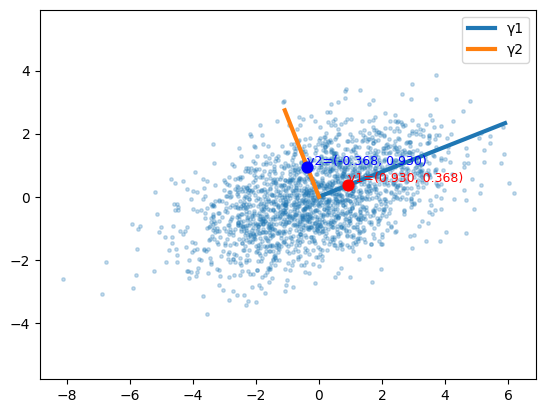

In [60]:

# Parameters
sigma1, sigma2, rho = 2.0, 1.2, 0.5
Sigma = np.array([[sigma1**2, rho*sigma1*sigma2],
                  [rho*sigma1*sigma2, sigma2**2]])

# Angle φ from closed form
phi = 0.5 * np.arctan2(2*rho*sigma1*sigma2, sigma1**2 - sigma2**2)

# Eigenvectors
gamma1 = np.array([np.cos(phi), np.sin(phi)])
gamma2 = np.array([-np.sin(phi), np.cos(phi)])

# Eigenvalues
lambda1 = gamma1 @ Sigma @ gamma1
lambda2 = gamma2 @ Sigma @ gamma2

print("φ =", phi)
print("γ1 =", gamma1, " λ1 =", lambda1)
print("γ2 =", gamma2, " λ2 =", lambda2)

# Plot samples and principal axes
X = np.random.multivariate_normal([0,0], Sigma, size=2000)
plt.scatter(X[:,0], X[:,1], s=6, alpha=0.25)
plt.plot([0, gamma1[0]*3*np.sqrt(lambda1)], [0, gamma1[1]*3*np.sqrt(lambda1)], lw=3, label="γ1")
plt.plot([0, gamma2[0]*3*np.sqrt(lambda2)], [0, gamma2[1]*3*np.sqrt(lambda2)], lw=3, label="γ2")

# Add points for γ1 and γ2 (unit eigenvectors)
plt.scatter(gamma1[0], gamma1[1], color="red", s=60, zorder=5)
plt.scatter(gamma2[0], gamma2[1], color="blue", s=60, zorder=5)

# Annotate with values
plt.text(gamma1[0], gamma1[1], f"γ1=({gamma1[0]:.3f}, {gamma1[1]:.3f})",
         fontsize=9, color="red", ha="left", va="bottom")
plt.text(gamma2[0], gamma2[1], f"γ2=({gamma2[0]:.3f}, {gamma2[1]:.3f})",
         fontsize=9, color="blue", ha="left", va="bottom")

plt.axis("equal"); plt.legend(); plt.show()

<font color="blue"><b>Ex. 3 (c)</b></font>

Demonstrate that:
$$
\Sigma = \sum_{i=1}^m \lambda_i \gamma_i \gamma_i'
$$
Because of $\Sigma \gamma_i = \lambda_i \gamma_i$, we have
$$
\Sigma \gamma_i \gamma_i' = \lambda_i \gamma_i \gamma_i'
$$
then
$$
\sum_{i=1}^m \Sigma \gamma_i \gamma_i' = \sum_{i=1}^m \lambda_i \gamma_i \gamma_i'.
$$
For
$$
\sum_{i=1}^m \gamma_i \gamma_i' = \gamma_1 \gamma_1' + \gamma_2 \gamma_2' + \cdots + \gamma_m \gamma_m',
$$
let $G = [\gamma_1, \gamma_2, \cdots, \gamma_m]$, $G$ is an orthogonal matrix.  
Then
$$
GG' = G^{-1} G = I,
$$
so
$$
\sum_{i=1}^m \gamma_i \gamma_i' = \gamma_1 \gamma_1' + \gamma_2 \gamma_2' + \cdots + \gamma_m \gamma_m' = I.
$$  
Therefore,  
$$
\Sigma = \sum_{i=1}^m \lambda_i \gamma_i \gamma_i'.
$$

<font color="blue"><b>Ex. 4 (a)</b></font>

The probability density function of an exponential random variable $X$ with parameter $\lambda > 0$ is  
$$
f_X(x) = \lambda e^{-\lambda x}, \quad x \geq 0
\;\;\;\Rightarrow\;\;\;
f_X(x) =
\begin{cases}
\lambda e^{-\lambda x}, & x \geq 0, \\
0, & x < 0.
\end{cases}
$$

The moment generating function (MGF) is  
$$
M_X(t) = \mathbb{E}[e^{tX}]
= \int_{0}^{\infty} e^{tx} f_X(x)\, dx
= \int_{0}^{\infty} e^{tx} \, \lambda e^{-\lambda x}\, dx
= \lambda \int_{0}^{\infty} e^{-(\lambda - t)x}\, dx.
$$
This integral converges only if $t < \lambda$.  
Find an antiderivative
$$
\int e^{-(\lambda - t)x}\,dx
= -\frac{1}{\lambda - t}\,e^{-(\lambda - t)x} + C.
$$
Apply bounds
$$
\int_{0}^{b} e^{-(\lambda - t)x}\,dx
=\left[-\frac{1}{\lambda - t}e^{-(\lambda - t)x}\right]_{x=0}^{x=b}
= -\frac{1}{\lambda - t}e^{-(\lambda - t)b} + \frac{1}{\lambda - t}.
$$

Take the limit as $b\;\Rightarrow\;\infty$ (using $t<\lambda$ so $e^{-(\lambda - t)b}\;\Rightarrow\; 0$)
$$
\int_{0}^{\infty} e^{-(\lambda - t)x}\,dx
=\lim_{b\to\infty}\left(\frac{1}{\lambda - t}-\frac{1}{\lambda - t}e^{-(\lambda - t)b}\right)
=\frac{1}{\lambda - t}.
$$
The moment generating function of $X \sim \text{Exponential}(\lambda)$ is  
$$
M_X(t) = \frac{\lambda}{\lambda - t}, \quad t < \lambda.
$$  

<font color="blue"><b>Ex. 4 (b)</b></font>

Checking Defenition of MGF at $t = 0$

$$
M_X(0) = \frac{\lambda}{\lambda - 0} = \frac{\lambda}{\lambda} = 1
$$
First derivative (with respect to $t$)
$$
M_X'(t) = \frac{d}{dt}\left(\frac{\lambda}{\lambda - t}\right)
= \frac{\lambda}{(\lambda - t)^2}.
$$
At $t = 0$:
$$
M_X'(0) = \frac{\lambda}{\lambda^2} = \frac{1}{\lambda}.
$$
So the mean is:
$$
\mathbb{E}[X] = M_X'(0) = \frac{1}{\lambda}.
$$
Second derivative (with respect to $t$)
$$
M_X''(t) = \frac{d}{dt}\left(\frac{\lambda}{(\lambda - t)^2}\right)
= \frac{2\lambda}{(\lambda - t)^3}.
$$
At $t = 0$:
$$
M_X''(0) = \frac{2\lambda}{\lambda^3} = \frac{2}{\lambda^2}.
$$

So the variance is:
$$
\mathrm{Var}(X) = M_X''(0) - \big(M_X'(0)\big)^2
= \frac{2}{\lambda^2} - \left(\frac{1}{\lambda}\right)^2
= \frac{1}{\lambda^2}.
$$

<font color="blue"><b>Ex. 4 (c)</b></font>

We want the probability that $X$ exceeds a fixed real $t > 0$:
$$
P(X > t) = \int_{t}^{\infty} f_X(x)\, dx.
$$
Since the PDF is
$$
f_X(x) = \lambda e^{-\lambda x}, \quad x \geq 0,
$$
we have
$$
P(X > t) = \int_{t}^{\infty} \lambda e^{-\lambda x}\, dx.
$$
Find antiderivative
$$
\int \lambda e^{-\lambda x}\, dx = -e^{-\lambda x} + C.
$$
Apply bounds
$$
\int_{t}^{\infty} \lambda e^{-\lambda x}\, dx
= \left[-e^{-\lambda x}\right]_{x=t}^{x=\infty}
= 0 - \left(-e^{-\lambda t}\right).
$$
Simplify
$$
P(X > t) = e^{-\lambda t}.
$$
For $X \sim \text{Exponential}(\lambda)$ and any $t > 0$:
$$
P(X > t) = e^{-\lambda t}.
$$

<font color="blue"><b>Ex. 4 (d)</b></font>

We want to show:
$$
P(X > s + t \mid X > s) = P(X > t), \quad \forall \; s,t > 0.
$$
Definition of conditional probability
$$
P(X > s + t \mid X > s) = \frac{P(X > s + t \;\cap\; X > s)}{P(X > s)}.
$$
But the event $\{X > s + t\}$ automatically implies $\{X > s\}$.  
So:
$$
P(X > s + t \mid X > s) = \frac{P(X > s + t)}{P(X > s)}.
$$
Use the survival function
From part (c) we know:
$$
P(X > u) = e^{-\lambda u}, \quad u > 0.
$$
So:
$$
P(X > s + t \mid X > s) = \frac{e^{-\lambda (s+t)}}{e^{-\lambda s}}.
$$
Simplify
$$
P(X > s + t \mid X > s) = e^{-\lambda t}.
$$
But this is exactly:
$$
P(X > t).
$$
The exponential distribution satisfies the **memoryless property**:
$$
P(X > s + t \mid X > s) = P(X > t), \quad \forall \; s,t > 0.
$$

<font color="blue"><b>Ex. 4 (e)</b></font>

Let $X_1, X_2, \dots, X_n$ be i.i.d. random variables with distribution
$$
X_i \sim \text{Exponential}(\lambda).
$$
We want to show that
$$
Y = \min \{X_1, X_2, \dots, X_n\}
$$
is also exponentially distributed.

Tail probability of the minimum. By definition:
$$
P(Y > t) = P(\min\{X_1, \dots, X_n\} > t).
$$
But the minimum exceeds $t$ if **all variables exceed $t$**.  
So:
$$
P(Y > t) = P(X_1 > t, X_2 > t, \dots, X_n > t).
$$
Use independence
Since the $X_i$ are independent:
$$
P(Y > t) = \prod_{i=1}^{n} P(X_i > t).
$$
Recall exponential tail probability
From part (c):
$$
P(X_i > t) = e^{-\lambda t}.
$$
Thus:
$$
P(Y > t) = \left(e^{-\lambda t}\right)^n = e^{-n \lambda t}.
$$
Identify the distribution
The survival function of $Y$ is:
$$
P(Y > t) = e^{-n \lambda t}, \quad t \geq 0.
$$
This is exactly the survival function of an exponential random variable with parameter $n\lambda$.
$$
Y = \min\{X_1, \dots, X_n\} \;\sim\; \text{Exponential}(n\lambda).
$$

<font color="blue"><b>Ex. 5 (a)</b></font>

Let $X \sim \text{Lognormal}(\mu, \sigma^2)$. Its PDF is:
$$
f(x;\mu,\sigma) =
\begin{cases}
\dfrac{1}{\sqrt{2\pi}\sigma x}\exp\!\left(-\dfrac{(\ln x - \mu)^2}{2\sigma^2}\right), & x > 0, \\
0, & x \leq 0.
\end{cases}
$$
Mean
$$
E[X] = \int_0^\infty x f(x)\, dx
$$
Substitute $y = \ln x \implies x = e^y, \, dx = e^y dy$:
$$
E[X] = \frac{1}{\sqrt{2\pi}\sigma}\int_{-\infty}^\infty
\exp\!\left( y - \frac{(y-\mu)^2}{2\sigma^2} \right) dy
$$
Complete the square in the exponent:
$$
y - \frac{(y-\mu)^2}{2\sigma^2}
= -\frac{(y-(\mu+\sigma^2))^2}{2\sigma^2} + \mu + \tfrac{1}{2}\sigma^2
$$
Thus,
$$
E[X] = e^{\mu + \tfrac{1}{2}\sigma^2}
$$
Second Moment
$$
E[X^2] = \int_0^\infty x^2 f(x)\, dx
= \frac{1}{\sqrt{2\pi}\sigma}\int_{-\infty}^\infty
e^{2y} \exp\!\left(-\frac{(y-\mu)^2}{2\sigma^2}\right) dy
$$
By the same method,
$$
E[X^2] = e^{2\mu + 2\sigma^2}
$$
Variance
$$
\text{Var}(X) = E[X^2] - (E[X])^2
= e^{2\mu+2\sigma^2} - e^{2\mu+\sigma^2}
$$
$$
\text{Var}(X) = \big(e^{\sigma^2} - 1\big)\,e^{2\mu+\sigma^2}
$$

<font color="blue"><b>Ex. 5 (b)</b></font>

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-2032304428.py:16: SyntaxWarning: invalid escape sequence '\m'
  plt.title("Lognormal PDF for different $(\mu,\sigma)$")


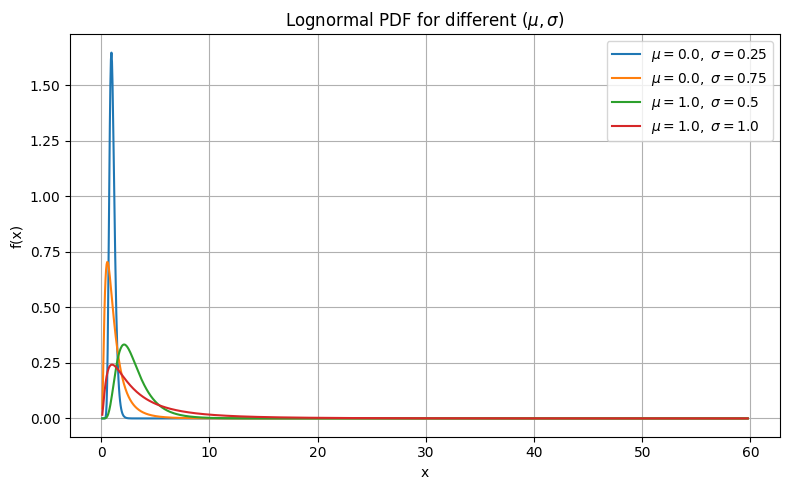

In [61]:
# Choose parameter pairs (μ, σ)
params = [(0.0, 0.25), (0.0, 0.75), (1.0, 0.5), (1.0, 1.0)]

# Build a common x-range using extreme quantiles across all params
q_lo, q_hi = 1e-3, 1 - 1e-3
lo = min(lognorm.ppf(q_lo, s=s, scale=np.exp(m)) for m, s in params)
hi = max(lognorm.ppf(q_hi, s=s, scale=np.exp(m)) for m, s in params)
x = np.linspace(lo, hi, 1200)

# Plot PDFs
plt.figure(figsize=(8,5))
for m, s in params:
    pdf = lognorm.pdf(x, s=s, scale=np.exp(m))
    plt.plot(x, pdf, label=fr"$\mu={m},\ \sigma={s}$")

plt.title("Lognormal PDF for different $(\mu,\sigma)$")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.grid(True); plt.legend()
plt.tight_layout(); plt.show()

<font color="blue"><b>Ex. 6</b></font>

Given that the radius of the circle is $1$. Suppose the diameter lies on the X-axis from $A(-1,0)$ to $B(1,0)$.  
The semicircle arc is above the X-axis with equation:
$$ y = \sqrt{1 - x^2}, \quad x \in [-1, 1]. $$
A random point $P$ is to be chosen on the **circumference** to form a right triangle $\triangle APB$.

The circumference of the boundary is:

$$ \frac{2\pi r}{2} + 2r = \pi + 2. $$
We set the coordinates of $P$ (randomly) as $(\cos\theta, \sin\theta)$.
- For $\theta \in [0,\pi]$: $P$ is on the semicircular arc ($y \geq 0$).  
- For $\theta \in [\pi,2\pi]$: $P$ is on the diameter ($y=0$).

For $\theta \in [0,\pi]$:
$$
PA = \sqrt{(\cos \theta - (-1))^2 + (\sin \theta - 0)^2}
= \sqrt{(\cos \theta + 1)^2 + \sin^2 \theta}
= \sqrt{2 + 2 \cos \theta} = 2|\cos (\theta/2)| = 2\cos(\theta/2)
$$

$$(\theta \in [0,\pi] \to \frac{\theta}{2} \in [0,\pi/2] \to \cos(\theta/2) \geq 0)$$

$$
PB = \sqrt{(\cos \theta - 1)^2 + (\sin \theta - 0)^2}
= \sqrt{(\cos \theta - 1)^2 + \sin^2 \theta}
= \sqrt{2 - 2 \cos \theta} = 2|\sin(\theta/2)| = 2\sin(\theta/2)
$$

$$(\theta \in [0,\pi] \to \frac{\theta}{2} \in [0,\pi/2] \to \sin(\theta/2) \geq 0)$$

The area of the triangle when $\theta \in [0,\pi]$:

$$
Area = \tfrac{1}{2} \times PA \times PB
= \tfrac{1}{2} \times 4\sin(\tfrac{\theta}{2})\cos(\tfrac{\theta}{2})
= 2\sin(\tfrac{\theta}{2})\cos(\tfrac{\theta}{2})
= \sin\theta
$$

When $\theta \in [\pi,2\pi]$, $P$ lies on the diameter, the area should be $0$.

Now we can calculate for the expected area:

$$
E[Area] = E[Area \mid \theta \in [0,\pi]] \cdot P(\theta \in [0,\pi]) + E[Area \mid \theta \in [\pi,2\pi]] \cdot P(\theta \in [\pi,2\pi])
$$

$$
E[Area \mid \theta \in [0,\pi]] = \frac{1}{\pi} \int_0^\pi \sin \theta \, d\theta
= \frac{1}{\pi}[-\cos \theta]_0^\pi
= \frac{1}{\pi}[-\cos \pi - (-\cos 0)]
= \frac{1}{\pi}[1+1] = \frac{2}{\pi}
$$

$$
E[Area \mid \theta \in [\pi,2\pi]] = 0
$$

$$
E[Area] = \Big(\frac{2}{\pi}\Big) \cdot \tfrac{1}{2} + 0 \cdot \tfrac{1}{2}
= \frac{2}{2\pi} = \frac{1}{\pi}
$$

Random θ = 2.571, Triangle area = 0.541


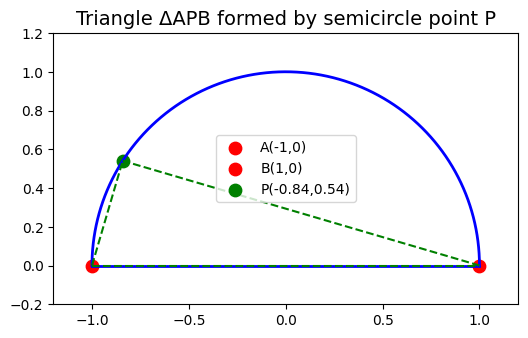

In [62]:
# Circle parameters
r = 1
theta = np.linspace(0, np.pi, 300)

# Semicircle coordinates
x = np.cos(theta)
y = np.sin(theta)

# Endpoints of diameter
A = (-1, 0)
B = (1, 0)

# Pick a random point P on the semicircle
theta_rand = np.random.uniform(0, np.pi)
P = (np.cos(theta_rand), np.sin(theta_rand))

# Compute area of triangle APB
area = 0.5 * abs((A[0]*(B[1]-P[1]) + B[0]*(P[1]-A[1]) + P[0]*(A[1]-B[1])))
print(f"Random θ = {theta_rand:.3f}, Triangle area = {area:.3f}")

# Plot
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(x, y, 'b', linewidth=2)  # semicircle
ax.plot([-1,1], [0,0], 'b', linewidth=2)  # diameter
ax.scatter(*A, color="red", s=80, label="A(-1,0)")
ax.scatter(*B, color="red", s=80, label="B(1,0)")
ax.scatter(*P, color="green", s=80, label=f"P({P[0]:.2f},{P[1]:.2f})")

# Draw triangle APB
ax.plot([A[0], P[0]], [A[1], P[1]], 'g--')
ax.plot([B[0], P[0]], [B[1], P[1]], 'g--')
ax.plot([A[0], B[0]], [A[1], B[1]], 'g--')

# Style
ax.set_aspect('equal')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-0.2, 1.2)
ax.set_title("Triangle ΔAPB formed by semicircle point P", fontsize=14)
ax.legend()
plt.show()

<font color="blue"><b>Ex. 7</b></font>

The **Touchard formula** gives the discordant permutation numbers $A_n$:

$A_n = \sum_{k=0}^n (-1)^k \,\frac{2n}{2n-k}\binom{2n-k}{k}(n-k)!.$

Compute $A_3$

\begin{aligned}
A_3 &= \sum_{k=0}^3 (-1)^k \frac{6}{6-k}\binom{6-k}{k}(3-k)! \\[6pt]
&= \; (+)\frac{6}{6}\binom{6}{0}(3)!
\;-\;\frac{6}{5}\binom{5}{1}(2)!
\;+\;\frac{6}{4}\binom{4}{2}(1)!
\;-\;\frac{6}{3}\binom{3}{3}(0)! \\[6pt]
&= 6 - 12 + 9 - 2 \\[6pt]
&= 1.
\end{aligned}

So we find that $A_3 = 1$.

This is a version of the **ménage problem**.  

- With men fixed in order, women must be permuted into $n$ slots so that wife $W_i$ does not sit in the two slots adjacent to $M_i$.  
- This is a permutation problem with forbidden positions, solved by rook polynomials.  

The number of valid women placements is

$$D_n = \sum_{k=0}^{n} (-1)^k \; r_k \; (n-k)!,$$
where

$$r_k = \frac{2n}{2n-k}\binom{2n-k}{k},$$

is the number of ways to place $k$ non-attacking rooks on the forbidden board.  

Including men’s permutations (with one man fixed to remove rotation):

$$N(n) = (n-1)! \, D_n.$$
$$\boxed{\,N(n) = (n-1)! \sum_{k=0}^{n} (-1)^k \frac{2n}{2n-k} \binom{2n-k}{k}\,(n-k)!\, }$$

In [63]:
import itertools, numpy as np
import matplotlib.pyplot as plt, matplotlib.animation as animation
from IPython.display import HTML
import ipywidgets as widgets

def visualize_couples(n=3):
    men   = [f"M{i+1}" for i in range(n)]
    women = [f"W{i+1}" for i in range(n)]
    men_seats   = list(range(0, 2*n, 2))
    women_seats = list(range(1, 2*n, 2))

    angles = np.linspace(0, 2*np.pi, 2*n, endpoint=False)
    pos = np.c_[np.cos(angles), np.sin(angles)]

    def is_valid_women_perm(perm):
        for seat_index, wife in zip(women_seats, perm):
            wife_id = int(wife[1:])  # W3 -> 3
            husband = men_seats[wife_id-1]
            if husband in ((seat_index-1)%(2*n), (seat_index+1)%(2*n)):
                return False
        return True

    valid_arrangements = [perm for perm in itertools.permutations(women)
                          if is_valid_women_perm(perm)]
    print(f"Number of valid seatings for n={n}: {len(valid_arrangements)}")

    if not valid_arrangements:
        print("No valid arrangements."); return

    fig, ax = plt.subplots(figsize=(6,6))

    def draw_arrangement(perm):
        ax.clear(); ax.set_aspect('equal'); ax.axis('off')
        ax.set_xlim(-1.4,1.4); ax.set_ylim(-1.4,1.4)
        ax.add_artist(plt.Circle((0,0),1.1,fill=False,ls='--',alpha=0.3))

        for i,m in enumerate(men):
            x,y = pos[men_seats[i]]
            ax.text(x,y,m,ha='center',va='center',
                    bbox=dict(boxstyle="circle,pad=0.3",facecolor="#cfe8ff",edgecolor="#2b6cb0"))
        for i,w in enumerate(perm):
            x,y = pos[women_seats[i]]
            ax.text(x,y,w,ha='center',va='center',
                    bbox=dict(boxstyle="circle,pad=0.3",facecolor="#ffd6e7",edgecolor="#ad1457"))
        ax.set_title("Valid seating (alternating sexes, distinct seatings up to rotation)")

    def update(frame):
        draw_arrangement(valid_arrangements[frame % len(valid_arrangements)])
        return []

    anim = animation.FuncAnimation(fig, update, frames=len(valid_arrangements),
                                   interval=1500, blit=False, repeat=True)
    display(HTML(anim.to_jshtml()))
    plt.close(fig)

widgets.interact(visualize_couples,
                 n=widgets.IntSlider(value=3, min=3, max=5, step=1, description="n couples"))


interactive(children=(IntSlider(value=3, description='n couples', max=5, min=3), Output()), _dom_classes=('wid…

<function __main__.visualize_couples(n=3)>

<font color="blue"><b>Ex. 8 (a)</b></font>

Suppose we have the correlation matrix

$$A = \begin{bmatrix}
1 & \rho \\
\rho & 1
\end{bmatrix}, \qquad -1 < \rho < 1.$$

The Cholesky decomposition seeks a triangular matrix $L$ with positive diagonal entries such that $A = L L^\top.$

Lower–triangular form
$$L = \begin{bmatrix}
1 & 0 \\
\rho & \sqrt{1-\rho^2}
\end{bmatrix}.$$

Check:
$$
L L^\top =
\begin{bmatrix}
1 & 0 \\
\rho & \sqrt{1-\rho^2}
\end{bmatrix}
\begin{bmatrix}
1 & \rho \\
0 & \sqrt{1-\rho^2}
\end{bmatrix}
=
\begin{bmatrix}
1 & \rho \\
\rho & 1
\end{bmatrix}.$$
Upper–triangular form

Equivalently, one can write
$$U = L^\top =
\begin{bmatrix}
1 & \rho \\
0 & \sqrt{1-\rho^2}
\end{bmatrix},$$
so that
$$A = U^\top U.$$


<font color="blue"><b>Ex. 8 (b)</b></font>

Given a real, symmetric, positive–definite matrix  
$$A \in \mathbb{R}^{n \times n},$$
the Cholesky decomposition finds a **lower triangular** matrix $L$ with positive diagonal entries such that  
$$A = L L^\top$$
Algorithm (step–by–step)
For $i = 1,2,\dots,n$ (rows):
- Compute the diagonal entry $L_{ii} = \sqrt{\,A_{ii} - \sum_{k=1}^{i-1} L_{ik}^2\,}$
For each $j = i+1, i+2, \dots, n$ (rows below the diagonal):
- Compute the off–diagonal entries
$L_{ji} = \frac{1}{L_{ii}} \left( A_{ji} - \sum_{k=1}^{i-1} L_{jk} L_{ik} \right)$
All entries above the diagonal are zero:
$$L_{ij} = 0 \quad \text{for } j > i.$$
Properties
- The complexity is $O(n^3)$ (similar to Gaussian elimination).  
- $L$ is unique if we require $L_{ii} > 0$.  
- Numerical stability requires $A$ to be strictly positive–definite.

<font color="blue"><b>Ex. 8 (c)</b></font>

In [64]:
from scipy.linalg import cholesky as scipy_chol

def cholesky_lower(A, tol=1e-12):
    A = np.array(A, float); n = A.shape[0]
    L = np.zeros_like(A)
    for i in range(n):
        s = np.dot(L[i,:i], L[i,:i])
        v = A[i,i]-s
        if v<=tol: raise np.linalg.LinAlgError("Not positive definite")
        L[i,i] = np.sqrt(v)
        for j in range(i+1,n):
            s = np.dot(L[j,:i], L[i,:i])
            L[j,i] = (A[j,i]-s)/L[i,i]
    return L

# Build SPD test matrices
rho=0.6; A2=np.array([[1,rho],[rho,1]])
B3=np.random.randn(3,3); A3=B3@B3.T+0.5*np.eye(3)
B5=np.random.randn(5,5); A5=B5@B5.T+1.0*np.eye(5)
tests=[("2x2",A2),("3x3",A3),("5x5",A5)]

for name,A in tests:
    Lc=cholesky_lower(A)
    Ln=np.linalg.cholesky(A)
    Ls=scipy_chol(A,lower=True)
    err_c=np.linalg.norm(A-Lc@Lc.T,'fro')
    err_n=np.linalg.norm(A-Ln@Ln.T,'fro')
    err_s=np.linalg.norm(A-Ls@Ls.T,'fro')

    print(f"\n=== {name} matrix ===")
    print("A =\n",np.round(A,4))
    print("\nCustom L =\n",np.round(Lc,4))
    print("\nNumPy L =\n",np.round(Ln,4))
    print("\nSciPy L =\n",np.round(Ls,4))
    print(f"\nErrors:  custom {err_c:.2e}, NumPy {err_n:.2e}, SciPy {err_s:.2e}")


=== 2x2 matrix ===
A =
 [[1.  0.6]
 [0.6 1. ]]

Custom L =
 [[1.  0. ]
 [0.6 0.8]]

NumPy L =
 [[1.  0. ]
 [0.6 0.8]]

SciPy L =
 [[1.  0. ]
 [0.6 0.8]]

Errors:  custom 0.00e+00, NumPy 0.00e+00, SciPy 0.00e+00

=== 3x3 matrix ===
A =
 [[ 1.73    0.0804  0.6702]
 [ 0.0804  1.6763 -1.9702]
 [ 0.6702 -1.9702  7.4895]]

Custom L =
 [[ 1.3153  0.      0.    ]
 [ 0.0611  1.2933  0.    ]
 [ 0.5095 -1.5475  2.1989]]

NumPy L =
 [[ 1.3153  0.      0.    ]
 [ 0.0611  1.2933  0.    ]
 [ 0.5095 -1.5475  2.1989]]

SciPy L =
 [[ 1.3153  0.      0.    ]
 [ 0.0611  1.2933  0.    ]
 [ 0.5095 -1.5475  2.1989]]

Errors:  custom 4.71e-16, NumPy 1.01e-15, SciPy 1.01e-15

=== 5x5 matrix ===
A =
 [[ 9.0738  0.5557 -3.6376  0.5779  0.2746]
 [ 0.5557  4.6172 -0.5254  1.6969  0.2843]
 [-3.6376 -0.5254  3.3279  0.2708 -0.3957]
 [ 0.5779  1.6969  0.2708  5.9667  0.5579]
 [ 0.2746  0.2843 -0.3957  0.5579  1.3112]]

Custom L =
 [[ 3.0123  0.      0.      0.      0.    ]
 [ 0.1845  2.1408  0.      0.      0.    ]


<font color="blue"><b>Ex. 8 (d)</b></font>

Suppose we want to simulate correlated random variables.  

Let $R \in \mathbb{R}^{p \times p}$ be a correlation matrix.  
Perform the **Cholesky factorization**:
$$
R = L L^\top,
$$
where $L$ is lower triangular with positive diagonal entries.

Generate independent samples

Let $Z \in \mathbb{R}^{n \times p}$ be a matrix of independent standardized samples:  
$$\mathbb{E}[Z] = 0, \quad \operatorname{Cov}(Z) = I_p$$
That is, each row $z_i$ is an independent draw with identity covariance.
Transform with $L$

Define the correlated samples:
$$X = Z L^\top.$$
So each row is $x_i = z_i L^\top$.

$$\operatorname{Cov}(x_i) = \mathbb{E}[x_i x_i^\top]
= \mathbb{E}[\, (z_i L^\top)(L z_i^\top)\,]
= L \,\mathbb{E}[z_i z_i^\top]\, L^\top
= L I_p L^\top
= L L^\top
= R$$
Therefore, the transformed samples $X$ have **exactly** the correlation matrix $R$. This proves that multiplying independent random draws by the Cholesky factor generates correlated variables with the desired correlation structure.


<font color="blue"><b>Ex. 8 (e)</b></font>

We want to generate synthetic data that preserves **pairwise correlations** of the original dataset without using Cholesky (which may fail under multicollinearity).  

Given $X \in \mathbb{R}^{n \times p}$:

- Sample mean: $\mu \in \mathbb{R}^p$  
- Standard deviations: $s \in \mathbb{R}^p$  
- Diagonal matrix: $D = \mathrm{diag}(s)$  

Then the covariance is $S = \dfrac{1}{n-1}(X - \mathbf{1}\mu^\top)^\top (X - \mathbf{1}\mu^\top)$

and the correlation matrix is $R = D^{-1} S D^{-1}$

Eigen-decompose  

$R = Q \Lambda Q^\top$

with $\Lambda = \mathrm{diag}(\lambda_1,\dots,\lambda_p)$.  
Clip eigenvalues:
$\tilde\lambda_i = \max(\lambda_i, \varepsilon), \quad \varepsilon > 0.$

Then  

$R^{1/2} = Q \tilde\Lambda^{1/2} Q^\top,$  

$\tilde\Lambda^{1/2} = \mathrm{diag}(\sqrt{\tilde\lambda_1},\dots,\sqrt{\tilde\lambda_p}).$

Generate latent samples.

Draw $Z \in \mathbb{R}^{m \times p}$ with rows $z_i \sim \mathcal{N}(0, I_p)$.  
Form  

$Y_{\text{lat}} = Z (R^{1/2})^\top.$

Then  

$\mathrm{Cov}(y_i) = R^{1/2} I_p (R^{1/2})^\top = R,$

so $Y_{\text{lat}}$ has the desired correlation.

Marginal preservation (Gaussian copula).

For each column $j$:

- Rank the latent values $y_{1j},\dots,y_{mj}$ into $r_{ij}$.  
- Compute pseudo-uniforms  

$u_{ij} = \dfrac{r_{ij}-0.5}{m}.$

- Map through the empirical quantile of the original column $X_{\cdot j}$:  

$y^{(\text{marg})}_{ij} = \hat F_j^{-1}(u_{ij}).$

This yields synthetic variables with the **original marginal distributions** and approximately the same correlations.

Since $Z$ has $\mathbb{E}[Z]=0$ and $\mathrm{Cov}(Z)=I_p$,

$\mathrm{Cov}\!\big(Z(R^{1/2})^\top\big) = R^{1/2}\,\mathrm{Cov}(Z)\,(R^{1/2})^\top = R.$

Clipping eigenvalues ensures numerical stability even if $R$ is nearly singular due to multicollinearity.


<font color="blue"><b>Ex. 9 (a)</b></font>

Consider the quadratic
$$
a x^2 + b x + c = 0,
$$
where $a,b,c$ are i.i.d. $\mathrm{Uniform}(0,1]$.

A quadratic has real roots if its discriminant is nonnegative:
$$
{\ \Delta = b^2 - 4ac \ge 0\ }.
$$

<font color="blue"><b>Ex. 9 (b)</b></font>

The condition is $b^2\ge 4ac$, i.e., $b\ge 2\sqrt{ac}$ (since $a,c,b\in(0,1]$).

Because $a$ and $c$ are usually not tiny, the threshold $2\sqrt{ac}$ is often fairly large, leaving a relatively small slice of the $b\in(0,1]$ range where the condition holds. We only have a chance when $ac\le \tfrac14$ (otherwise $2\sqrt{ac}>1$). So the “eligible” region in $(a,c)$ is limited, and within it $b$ still needs to be big.

Putting that together, a reasonable ballpark guess is that the probability is around $1/4;(\approx 0.25)$. Below $1/2$ and closer to a quarter than to a tenth.

<font color="blue"><b>Ex. 9 (c)</b></font>

If we look closer at how $a$ and $c$ are distributed, their product $ac$ is not “typically medium”; it is actually skewed strongly toward very small values (there are many more pairs with small product than with product near $1$). Whenever $ac$ is small, the threshold $2\sqrt{ac}$ is also small, so it’s relatively easy for $b$ to exceed it.

So, counter to the earlier intuition, the actual probability ends up being slightly larger than the rough guess of one-quarter.

<font color="blue"><b>Ex. 9 (d)</b></font>

We want the probability

$P = \mathbb{P}(b^2 \geq 4ac),$

where $a, b, c \sim \text{Unif}(0,1)$ i.i.d.

Integral formulation
$P = \iiint_{[0,1]^3} \mathbf{1}\{b^2 \geq 4ac\}\, da\, db\, dc.$

For fixed $(a,c)$, the contribution of $b$ is

$\int_0^1 \mathbf{1}\{b \geq 2\sqrt{ac}\}\, db
=
\begin{cases}
1 - 2\sqrt{ac}, & ac \leq \tfrac{1}{4}, \\[6pt]
0, & ac > \tfrac{1}{4}.
\end{cases}$

Double integral

Thus,

$P = \int_0^1 \int_0^{\min(1,\;\frac{1}{4a})} (1 - 2\sqrt{ac})\, dc\, da.$

Split into two regions:

$P = I_1 + I_2,$

where  

- For $a \leq \tfrac{1}{4}$, upper limit = $1$:  

$I_1 = \int_0^{1/4} \int_0^1 (1 - 2\sqrt{ac})\, dc\, da.$

- For $a > \tfrac{1}{4}$, upper limit = $\tfrac{1}{4a}$:  

$I_2 = \int_{1/4}^1 \int_0^{1/(4a)} (1 - 2\sqrt{ac})\, dc\, da.$

Evaluate $I_1$

$\int_0^1 (1 - 2\sqrt{ac})\, dc
= 1 - 2\sqrt{a}\int_0^1 \sqrt{c}\, dc
= 1 - \tfrac{4}{3}\sqrt{a}.$

So,

$I_1 = \int_0^{1/4} \left(1 - \tfrac{4}{3}\sqrt{a}\right)\, da
= \left[a - \tfrac{8}{9}a^{3/2}\right]_0^{1/4}
= \tfrac{5}{36}.$

Evaluate $I_2$

$\int_0^{1/(4a)} (1 - 2\sqrt{ac})\, dc
= \left[c - \tfrac{4}{3}\sqrt{a} \, c^{3/2}\right]_0^{1/(4a)}
= \tfrac{1}{12a}.$

So,

$I_2 = \int_{1/4}^1 \tfrac{1}{12a}\, da
= \tfrac{1}{12}[\ln a]_{1/4}^1
= \tfrac{1}{6}\ln 2.$

$P = \tfrac{5}{36} + \tfrac{1}{6}\ln 2$

Numerical value:

$P \approx 0.2544.$

In [65]:
def analytic_probability():
    """
    Exact probability that b^2 >= 4ac
    when a, b, c ~ Uniform(0,1) i.i.d.
    """
    return 5/36 + (1/6)*math.log(2)

if __name__ == "__main__":
    result = analytic_probability()
    print(f"Exact probability = {result:.9f}")
    print("Formula: 5/36 + (1/6)*ln(2)")

Exact probability = 0.254413419
Formula: 5/36 + (1/6)*ln(2)


<font color="blue"><b>Ex. 9 (e)</b></font>

The Monte Carlo simulation estimates the probability by randomly generating many triples
$(a,b,c)$ from the uniform distribution on $(0,1)$. For each trial, we check whether the
discriminant condition $b^2 \geq 4ac$ holds. Each success increases the count, and the
ratio of successes to total trials gives the estimate of the probability.  

As the number of runs $N$ increases, the accuracy improves. With $N=10{,}000$, the relative
error is about $1.5\%$, but already by $N=50{,}000$ it falls below $0.1\%$. For
$N=500{,}000$ and $N=1{,}000{,}000$, the estimates are extremely close to the exact
value $P = \tfrac{5}{36} + \tfrac{1}{6}\ln 2 \approx 0.2544$, with errors only on the
order of $10^{-4}$.  

This behavior matches the theoretical expectation: the standard error of a Monte Carlo
estimate decreases at the rate $1/\sqrt{N}$. In practice, this means that even a moderate
number of runs produces a good approximation, and with one million runs the simulation
essentially reproduces the analytic answer.


In [66]:
EXACT = 5/36 + (1/6)*math.log(2)

def mc(n, seed=42):
    rng = random.Random(seed)
    hits = sum((lambda a,b,c: b*b >= 4*a*c)(rng.random(), rng.random(), rng.random()) for _ in range(n))
    p = hits/n
    abs_err = abs(p-EXACT)
    rel_err = abs_err/EXACT
    se = (p*(1-p)/n)**0.5
    print(f"N={n:,}  Estimate={p:.6f}  AbsErr={abs_err:.6f}  RelErr={rel_err:.3%}  SE={se:.6f}")

for N in [10_000, 50_000, 500_000, 1_000_000]:
    mc(N)

N=10,000  Estimate=0.250500  AbsErr=0.003913  RelErr=1.538%  SE=0.004333
N=50,000  Estimate=0.254160  AbsErr=0.000253  RelErr=0.100%  SE=0.001947
N=500,000  Estimate=0.254766  AbsErr=0.000353  RelErr=0.139%  SE=0.000616
N=1,000,000  Estimate=0.254787  AbsErr=0.000374  RelErr=0.147%  SE=0.000436


<font color="blue"><b>Ex. 9 (f)</b></font>

Whitening transforms the data so that it has mean $0$ and covariance equal to the identity matrix.  
In our case, the original variables $a, b, c \sim \text{Unif}(0,1)$ are already independent and have the same variance $1/12$.  
The whitening procedure works correctly: after transformation, the mean is close to $0$ and the covariance is close to $I$.  

However, whitening also changes the distribution from uniform to something different.  
Since the probability we want, $\mathbb{P}(b^2 \geq 4ac)$, is defined for the original uniform variables, whitening cannot be applied to improve the Monte Carlo estimation.

In [67]:
# Generate samples
N = 10000
X = np.random.rand(N, 3)   # a,b,c ~ Unif(0,1)

# Compute mean and covariance
mu = X.mean(axis=0)
Sigma = np.cov(X, rowvar=False)

# Whitening transform: (X - mu) * Sigma^{-1/2}
eigvals, eigvecs = np.linalg.eigh(Sigma)
Sigma_inv_sqrt = eigvecs @ np.diag(1/np.sqrt(eigvals)) @ eigvecs.T
X_white = (X - mu) @ Sigma_inv_sqrt

print("Original mean:", mu)
print("Original covariance:\n", Sigma)
print("\nAfter whitening:")
print("Mean (approx):", X_white.mean(axis=0))
print("Covariance (approx):\n", np.cov(X_white, rowvar=False))


Original mean: [0.49897428 0.50160027 0.50030139]
Original covariance:
 [[ 0.08257872 -0.00073401  0.00040898]
 [-0.00073401  0.08390138  0.00063239]
 [ 0.00040898  0.00063239  0.08408816]]

After whitening:
Mean (approx): [2.83946200e-15 1.83578153e-15 2.28188579e-15]
Covariance (approx):
 [[ 1.00000000e+00 -5.79860858e-16  2.61661324e-16]
 [-5.79860858e-16  1.00000000e+00 -6.55852121e-16]
 [ 2.61661324e-16 -6.55852121e-16  1.00000000e+00]]


<font color="blue"><b>Ex. 10 (a)</b></font>

**Create a yield curve using constant maturity Yield**
We use the following tenors: 1M, 3M, 6M, 1Y, 2Y, 3Y, 5Y, 7Y, 10Y, 20Y, 30Y

In [68]:
ticker = ['DGS1MO', 'DGS3MO', 'DGS6MO','DGS1','DGS2', 'DGS3', 'DGS5','DGS7', 'DGS10','DGS20','DGS30']
sdt = dt.datetime(2014, 9, 28)
edt = dt.datetime(2024, 9, 27)
source = 'fred'
yieldcurve = pd.DataFrame(web.DataReader(ticker, source, sdt, edt))
yieldcurve = yieldcurve.dropna()
yieldcurve.to_csv('yieldcurvenona.csv')

In [69]:
yieldcurve.head(10)

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30
DATE,,,,,,,,,,,
2014-09-29,0.01,0.02,0.05,0.11,0.58,1.06,1.77,2.21,2.50,2.95,3.18
2014-09-30,0.02,0.02,0.03,0.13,0.58,1.07,1.78,2.22,2.52,2.98,3.21
2014-10-01,0.01,0.02,0.04,0.10,0.53,1.00,1.69,2.12,2.42,2.87,3.12
2014-10-02,0.01,0.01,0.03,0.10,0.53,1.01,1.70,2.14,2.44,2.90,3.15
2014-10-03,0.01,0.01,0.03,0.11,0.57,1.05,1.73,2.16,2.45,2.89,3.13
2014-10-06,0.01,0.02,0.05,0.11,0.54,1.02,1.70,2.13,2.43,2.88,3.12
2014-10-07,0.02,0.02,0.04,0.10,0.52,0.98,1.64,2.06,2.36,2.81,3.06
2014-10-08,0.01,0.01,0.05,0.10,0.46,0.90,1.57,2.02,2.35,2.82,3.07
2014-10-09,0.02,0.01,0.05,0.10,0.46,0.91,1.58,2.02,2.34,2.81,3.07


In [70]:
yieldcurve.tail(10)

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30
DATE,,,,,,,,,,,
2024-09-16,5.11,4.96,4.55,3.96,3.56,3.42,3.41,3.51,3.63,4.01,3.94
2024-09-17,5.05,4.95,4.55,3.99,3.59,3.45,3.44,3.53,3.65,4.02,3.96
2024-09-18,4.91,4.84,4.50,3.95,3.61,3.49,3.47,3.58,3.70,4.08,4.03
2024-09-19,4.89,4.80,4.46,3.93,3.59,3.47,3.49,3.60,3.73,4.11,4.06
2024-09-20,4.87,4.75,4.43,3.92,3.55,3.46,3.48,3.59,3.73,4.10,4.07
2024-09-23,4.85,4.72,4.40,3.91,3.57,3.47,3.51,3.62,3.75,4.12,4.09
2024-09-24,4.78,4.69,4.36,3.88,3.49,3.44,3.47,3.60,3.74,4.13,4.09
2024-09-25,4.79,4.69,4.36,3.89,3.53,3.49,3.52,3.65,3.79,4.18,4.14
2024-09-26,4.90,4.68,4.38,3.96,3.60,3.54,3.55,3.65,3.79,4.17,4.12


<font color="blue"><b>Ex. 10 (b)</b></font>

**US Treasury Yield Curve — Variable Definitions**

| Variable   | Definition |
|----------|------------|
| DATE     | Observation date (business days only, weekends/holidays excluded). |
| DGS1MO   | Yield (%) on **1-Month US Treasury Bill** (constant maturity). |
| DGS3MO   | Yield (%) on **3-Month US Treasury Bill** (constant maturity). |
| DGS6MO   | Yield (%) on **6-Month US Treasury Bill** (constant maturity). |
| DGS1     | Yield (%) on **1-Year US Treasury Note** (constant maturity). |
| DGS2     | Yield (%) on **2-Year US Treasury Note** (constant maturity). |
| DGS3     | Yield (%) on **3-Year US Treasury Note** (constant maturity). |
| DGS5     | Yield (%) on **5-Year US Treasury Note** (constant maturity). |
| DGS7     | Yield (%) on **7-Year US Treasury Note** (constant maturity). |
| DGS10    | Yield (%) on **10-Year US Treasury Note** (constant maturity), often used as the benchmark risk-free rate. |
| DGS20    | Yield (%) on **20-Year US Treasury Bond** (constant maturity). |
| DGS30    | Yield (%) on **30-Year US Treasury Bond** (constant maturity), long-term government borrowing rate. |


<font color="blue"><b>Ex. 10 (c)</b></font>

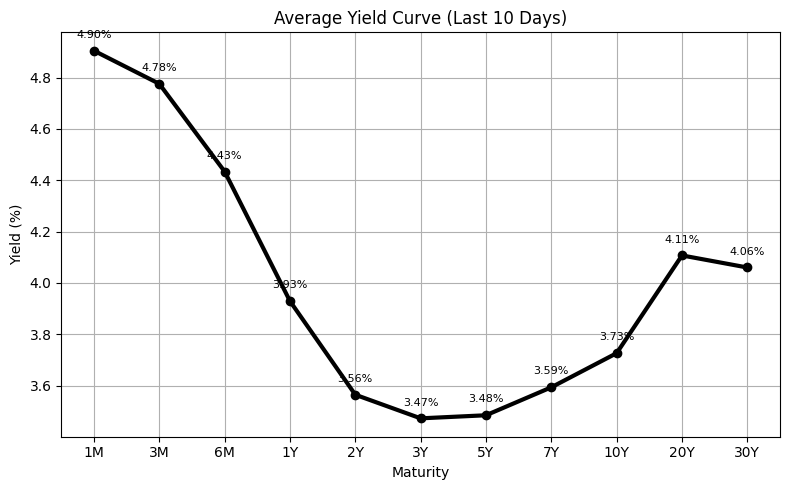

In [71]:
maturity_labels = ["1M","3M","6M","1Y","2Y","3Y","5Y","7Y","10Y","20Y","30Y"]
cols = ["DGS1MO","DGS3MO","DGS6MO","DGS1","DGS2","DGS3",
        "DGS5","DGS7","DGS10","DGS20","DGS30"]

# Last 10 rows
df10 = yieldcurve.tail(10)

# Average curve
avg_curve = df10[cols].mean().values

# Plot average curve
plt.figure(figsize=(8,5))
plt.plot(maturity_labels, avg_curve, marker="o", linewidth=3, color="black")
plt.title("Average Yield Curve (Last 10 Days)")
plt.xlabel("Maturity"); plt.ylabel("Yield (%)")
plt.grid(True)

# Annotate each point with its yield value
for i, (x, y) in enumerate(zip(maturity_labels, avg_curve)):
    plt.text(i, y + 0.05, f"{y:.2f}%", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

In [72]:
cols = ["DGS1MO","DGS3MO","DGS6MO","DGS1","DGS2","DGS3",
        "DGS5","DGS7","DGS10","DGS20","DGS30"]

# Last 10 rows
df10 = yieldcurve.tail(10)

# Average curve
avg_curve = df10[cols].mean().values

# Shape classifier
def classify_curve(y):
    diffs = np.diff(y)
    if np.all(diffs >= 0): return "upslope (normal)"
    if np.all(diffs <= 0): return "downslope (inverted)"
    if y[0] > y[-1] and 0 < np.argmin(y) < len(y)-1: return "inverted with hump/U-shape"
    return "mixed/flat"

shape = classify_curve(avg_curve)
print("Yield Curve Shape (last 10 days avg):", shape)

# Text interpretation
if "inverted" in shape:
    print("\nInterpretation: The curve is inverted at the short end and turns upward at long maturities, "
          "showing a humped/U-shape. This suggests markets expect slower growth and future Fed rate cuts, "
          "while long-term yields include a risk premium for inflation and fiscal uncertainty.")
elif "upslope" in shape:
    print("\nInterpretation: A normal upward-sloping curve, consistent with growth expectations and rising inflation.")
elif "downslope" in shape:
    print("\nInterpretation: Fully inverted, often a strong recession signal.")
else:
    print("\nInterpretation: Mixed/flat shape, signaling market uncertainty.")

Yield Curve Shape (last 10 days avg): inverted with hump/U-shape

Interpretation: The curve is inverted at the short end and turns upward at long maturities, showing a humped/U-shape. This suggests markets expect slower growth and future Fed rate cuts, while long-term yields include a risk premium for inflation and fiscal uncertainty.


<font color="blue"><b>Ex. 10 (d)</b></font>

In [73]:
# Calculate daily percentage change for each maturity
yieldcurve_pct = yieldcurve.pct_change() * 100  # convert to %

# Drop the first row (NaN because no previous day)
yieldcurve_pct = yieldcurve_pct.dropna()

# Show dimensions and a preview
print("Shape:", yieldcurve_pct.shape)
print(yieldcurve_pct.tail())

Shape: (2465, 11)
              DGS1MO    DGS3MO    DGS6MO      DGS1      DGS2      DGS3  \
DATE                                                                     
2024-09-23 -0.410678 -0.631579 -0.677201 -0.255102  0.563380  0.289017   
2024-09-24 -1.443299 -0.635593 -0.909091 -0.767263 -2.240896 -0.864553   
2024-09-25  0.209205  0.000000  0.000000  0.257732  1.146132  1.453488   
2024-09-26  2.296451 -0.213220  0.458716  1.799486  1.983003  1.432665   
2024-09-27  0.000000  0.000000 -0.684932 -1.515152 -1.388889 -1.412429   

                DGS5      DGS7     DGS10     DGS20     DGS30  
DATE                                                          
2024-09-23  0.862069  0.835655  0.536193  0.487805  0.491400  
2024-09-24 -1.139601 -0.552486 -0.266667  0.242718  0.000000  
2024-09-25  1.440922  1.388889  1.336898  1.210654  1.222494  
2024-09-26  0.852273  0.000000  0.000000 -0.239234 -0.483092  
2024-09-27 -1.408451 -1.369863 -1.055409 -0.479616 -0.485437  


<font color="blue"><b>Ex. 10 (e)</b></font>

In [74]:
# Drop NaN for Short-term periods
yieldcurve_pct = yieldcurve_pct.replace([np.inf, -np.inf], np.nan).dropna()

# Mean and standard deviation for each maturity
stats = pd.DataFrame({
    "Mean % Change": yieldcurve_pct.mean(),
    "Std Dev % Change": yieldcurve_pct.std()
})
print(stats)

        Mean % Change  Std Dev % Change
DGS1MO       2.132561         29.659599
DGS3MO       1.822314         20.731896
DGS6MO       0.714407         12.679779
DGS1         0.330069          5.572245
DGS2         0.238056          5.088652
DGS3         0.177011          4.548485
DGS5         0.126032          3.887440
DGS7         0.088768          3.235702
DGS10        0.075093          3.022600
DGS20        0.050713          2.392571
DGS30        0.041344          2.167882


<font color="blue"><b>Ex. 10 (f)</b></font>

          DGS1MO    DGS3MO    DGS6MO      DGS1      DGS2      DGS3      DGS5  \
DGS1MO  1.000000  0.187286  0.214612  0.082245  0.016076  0.005731 -0.009241   
DGS3MO  0.187286  1.000000  0.443889  0.149841  0.079273  0.063138  0.050279   
DGS6MO  0.214612  0.443889  1.000000  0.240770  0.082758  0.100727  0.086116   
DGS1    0.082245  0.149841  0.240770  1.000000  0.415908  0.425434  0.385952   
DGS2    0.016076  0.079273  0.082758  0.415908  1.000000  0.777310  0.741141   
DGS3    0.005731  0.063138  0.100727  0.425434  0.777310  1.000000  0.910120   
DGS5   -0.009241  0.050279  0.086116  0.385952  0.741141  0.910120  1.000000   
DGS7   -0.011884  0.048313  0.073081  0.371681  0.682418  0.855127  0.953121   
DGS10  -0.013219  0.058889  0.090964  0.344419  0.613000  0.788547  0.901484   
DGS20  -0.004297  0.063351  0.099999  0.312424  0.529120  0.703019  0.821751   
DGS30  -0.000421  0.069836  0.103654  0.303531  0.493448  0.657377  0.778036   

            DGS7     DGS10     DGS20   

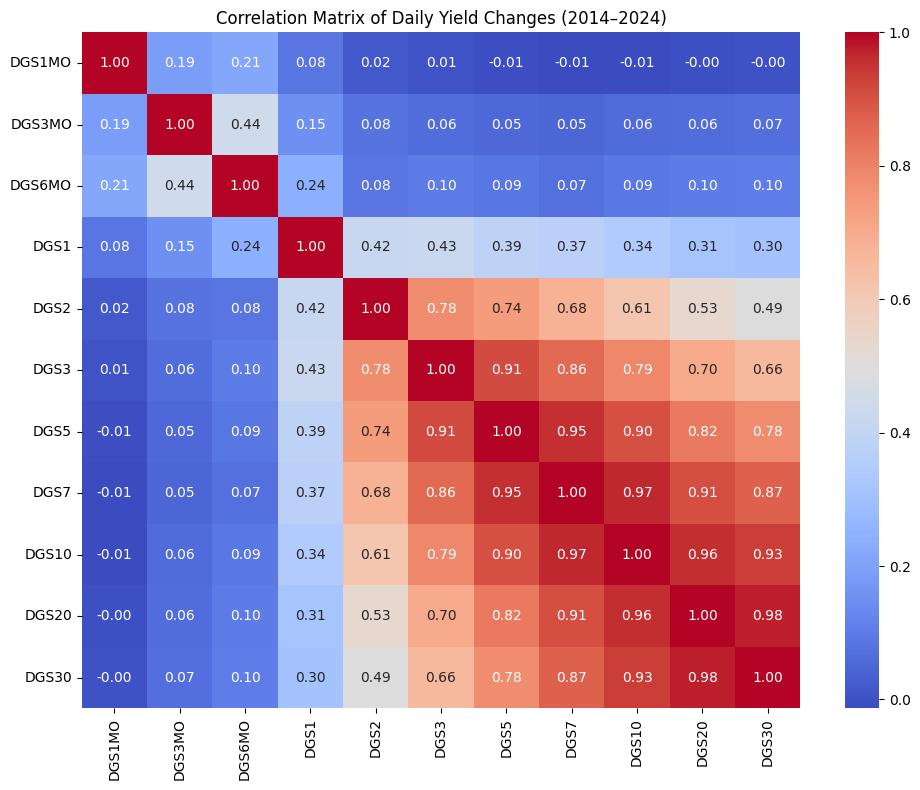

In [75]:
# Correlation matrix of daily % changes
corr_matrix = yieldcurve_pct.corr()

print(corr_matrix)

# Heatmap for visualization
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Daily Yield Changes (2014–2024)")
plt.tight_layout()
plt.show()

<font color="blue"><b>Ex. 10 (g)</b></font>

Yes, the correlation matrix you calculated is positive semi-definite (since the minimum eigenvalue ≈ 0.017 > 0).

In [76]:
eigvals = np.linalg.eigvalsh(corr_matrix.values)   # corr_matrix from yieldcurve_pct.corr()
print("Minimum eigenvalue:", eigvals.min())
print("Is PSD (within tolerance)?", np.all(eigvals >= -1e-10))

Minimum eigenvalue: 0.017467877677062895
Is PSD (within tolerance)? True


<font color="blue"><b>Ex. 10 (h)</b></font>

In [77]:
# Correlation matrix of yield changes
corr = yieldcurve_pct.corr()

# Eigen decomposition (symmetric matrix)
eigvals, eigvecs = np.linalg.eigh(corr.values)

# Sort in descending order
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Eigenvalues + explained variance
eigvals_df = pd.DataFrame({
    "Eigenvalue": eigvals,
    "Explained Variance %": eigvals / eigvals.sum() * 100
})

# Eigenvectors for all components
eigvecs_df = pd.DataFrame(eigvecs,
                          index=corr.columns,
                          columns=[f"PC{i+1}" for i in range(len(eigvals))])

# Results
print("Eigenvalues:\n", eigvals_df.round(4))
print("\nEigenvectors:\n", eigvecs_df.round(3))

Eigenvalues:
     Eigenvalue  Explained Variance %
0       6.0494               54.9949
1       1.6352               14.8657
2       0.9091                8.2642
3       0.8594                7.8128
4       0.6300                5.7272
5       0.5271                4.7922
6       0.2270                2.0635
7       0.0895                0.8132
8       0.0346                0.3146
9       0.0212                0.1928
10      0.0175                0.1588

Eigenvectors:
           PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8    PC9   PC10  \
DGS1MO -0.006 -0.422  0.251 -0.870  0.019 -0.042  0.008  0.006 -0.002 -0.001   
DGS3MO -0.042 -0.592  0.157  0.368  0.451 -0.531  0.041  0.005  0.002 -0.003   
DGS6MO -0.060 -0.616  0.063  0.279 -0.252  0.687 -0.016  0.022 -0.011  0.004   
DGS1   -0.190 -0.269 -0.646 -0.048 -0.566 -0.387  0.028  0.030  0.007 -0.007   
DGS2   -0.306 -0.027 -0.428 -0.113  0.456  0.185 -0.682  0.041 -0.016 -0.010   
DGS3   -0.363  0.011 -0.228 -0.071  0.263  0.1

<font color="blue"><b>Ex. 10 (i)</b></font>

Factor Loadings (first 3 components):

          PC1    PC2    PC3
DGS1MO -0.217 -0.135 -0.153
DGS3MO -0.211  0.020  0.156
DGS6MO -0.200  0.041  0.133
DGS1    0.061  0.181 -0.055
DGS2    0.274  0.108 -0.064
DGS3    0.349  0.059 -0.031
DGS5    0.391  0.015 -0.007
DGS7    0.407 -0.019  0.013
DGS10   0.402 -0.047  0.035
DGS20   0.383 -0.073  0.052
DGS30   0.369 -0.081  0.058


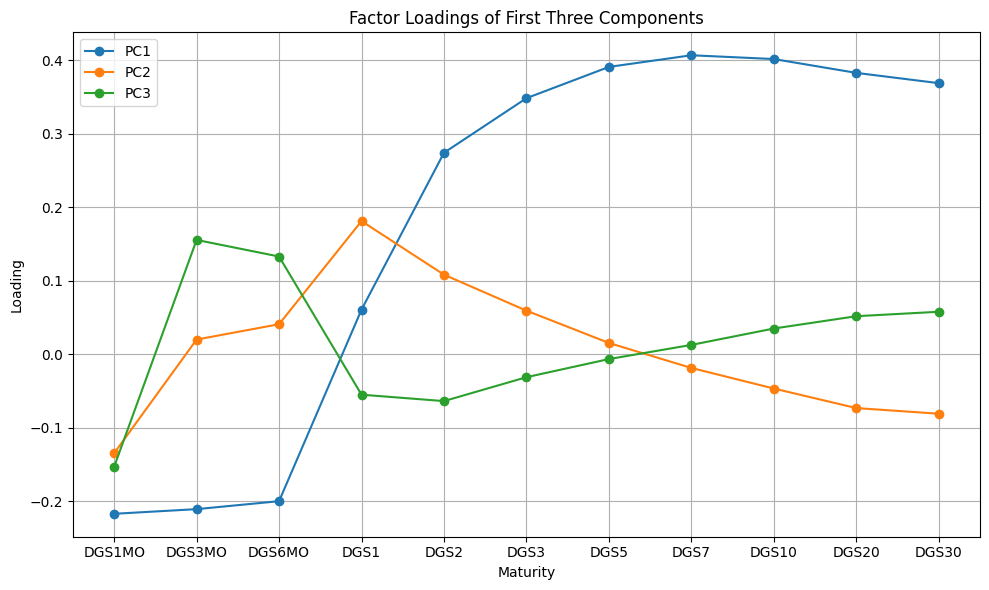

In [78]:
# Correlation matrix of yield changes
corr = yieldcurve_pct.corr()

# PCA
pca = PCA()
pca.fit(corr)

# Factor loadings (eigenvectors scaled by sqrt(eigenvalues))
loadings = pca.components_.T * (pca.explained_variance_**0.5)

# Put loadings in DataFrame
loadings_df = pd.DataFrame(loadings[:, :3],
                           index=corr.columns,
                           columns=["PC1","PC2","PC3"])

print("Factor Loadings (first 3 components):\n")
print(loadings_df.round(3))

# Plot loadings
plt.figure(figsize=(10,6))
for i, comp in enumerate(loadings_df.columns, start=1):
    plt.plot(corr.columns, loadings_df[comp], marker="o", label=comp)
plt.title("Factor Loadings of First Three Components")
plt.xlabel("Maturity")
plt.ylabel("Loading")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<font color="blue"><b>Ex. 10 (j)</b></font>

In Principal Component Analysis (PCA), the **total variation** of the dataset is defined as the **sum of all eigenvalues** of the covariance (or correlation) matrix:
$$
\text{Total Variation} = \sum_{i=1}^{n} \lambda_i
$$
where $\lambda_i$ are the eigenvalues.

Each eigenvalue represents the variance explained by one principal component (PC).

The explained variance ratio of the $k$-th component is:

$$
\text{Explained Variance Ratio of PC}_k = \frac{\lambda_k}{\sum_{i=1}^n \lambda_i}
$$

For a **correlation matrix** of $n$ variables, the diagonal elements are all $1$, so the trace is $n$.

Since the sum of eigenvalues equals the trace, the **total variation** is also $n$:
$$
\sum_{i=1}^n \lambda_i = \text{trace}(\Sigma) = n
$$

In [79]:
# Correlation matrix
corr = yieldcurve_pct.corr()

# Eigen decomposition
eigvals, eigvecs = np.linalg.eigh(corr.values)

# Sort descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]

# Explained variance ratios
explained_var_ratio = eigvals / eigvals.sum()
cumulative_var_ratio = explained_var_ratio.cumsum()

# Put in DataFrame
explained_df = pd.DataFrame({
    "Eigenvalue": eigvals,
    "Explained %": explained_var_ratio * 100,
    "Cumulative %": cumulative_var_ratio * 100
})

print(explained_df.round(3))

# How many PCs to exceed 95%?
num_pcs = np.argmax(cumulative_var_ratio >= 0.95) + 1
print(f"\nNumber of PCs needed to explain >95% variation: {num_pcs}")

    Eigenvalue  Explained %  Cumulative %
0        6.049       54.995        54.995
1        1.635       14.866        69.861
2        0.909        8.264        78.125
3        0.859        7.813        85.938
4        0.630        5.727        91.665
5        0.527        4.792        96.457
6        0.227        2.064        98.521
7        0.089        0.813        99.334
8        0.035        0.315        99.648
9        0.021        0.193        99.841
10       0.017        0.159       100.000

Number of PCs needed to explain >95% variation: 6


<font color="blue"><b>Ex. 10 (k)</b></font>

In [80]:
# Daily yield CHANGES in basis points (bp). (Yields are in %, so diff()*100 = bp.)
bp = yieldcurve[cols].diff().dropna() * 100.0     # shape T x 11

# PCA on the COVARIANCE of bp changes (loadings in bp per 1 unit factor move)
Sigma = np.cov(bp.values, rowvar=False)          # 11 x 11
eigvals, eigvecs = np.linalg.eigh(Sigma)         # symmetric
idx = np.argsort(eigvals)[::-1]                  # sort descending
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]                        # columns are eigenvectors (loadings)

# Factor score time series (historical component moves)
scores = bp.values @ eigvecs                     # T x 11

# Extreme 5th/95th percentiles for the first 3 components
q05 = np.percentile(scores[:, :3], 5, axis=0)
q95 = np.percentile(scores[:, :3], 95, axis=0)

# Build 6 single-factor extreme scenarios: Δy(bp) = quantile * loading_vector
scenarios = {
    "PC1 down by 5%": q05[0] * eigvecs[:, 0],
    "PC1 up by 95%":  q95[0] * eigvecs[:, 0],
    "PC2 down by 5%": q05[1] * eigvecs[:, 1],
    "PC2 up by 95%":  q95[1] * eigvecs[:, 1],
    "PC3 down by 5%": q05[2] * eigvecs[:, 2],
    "PC3 up by 95%":  q95[2] * eigvecs[:, 2],
}
scen_bp = pd.DataFrame(scenarios, index=maturity_labels)
print("Extreme single-component scenarios (Δy in bp):")
print(scen_bp.round(1))

# BASE curve (latest): convert bp by /100
base_curve = yieldcurve[cols].iloc[-1].values    # in %
shocked_curves = {name: base_curve + (shock/100.0) for name, shock in scenarios.items()}
shocked_df = pd.DataFrame(shocked_curves, index=maturity_labels)
print("\nShocked yield curves (levels in %):")
print(shocked_df.round(3))

Extreme single-component scenarios (Δy in bp):
     PC1 down by 5%  PC1 up by 95%  PC2 down by 5%  PC2 up by 95%  \
1M              0.4           -0.4             4.1           -3.9   
3M              1.6           -1.5             1.9           -1.8   
6M              2.7           -2.6             2.2           -2.0   
1Y              4.6           -4.4             2.8           -2.6   
2Y              7.3           -6.9             2.3           -2.1   
3Y              8.1           -7.7             1.5           -1.4   
5Y              8.7           -8.2             0.3           -0.2   
7Y              8.8           -8.3            -0.7            0.7   
10Y             8.3           -7.8            -1.4            1.3   
20Y             7.5           -7.1            -2.4            2.2   
30Y             7.1           -6.7            -2.6            2.5   

     PC3 down by 5%  PC3 up by 95%  
1M             -4.6            4.8  
3M              0.2           -0.2  
6M           

<font color="blue"><b>Ex. 10 (l)</b></font>

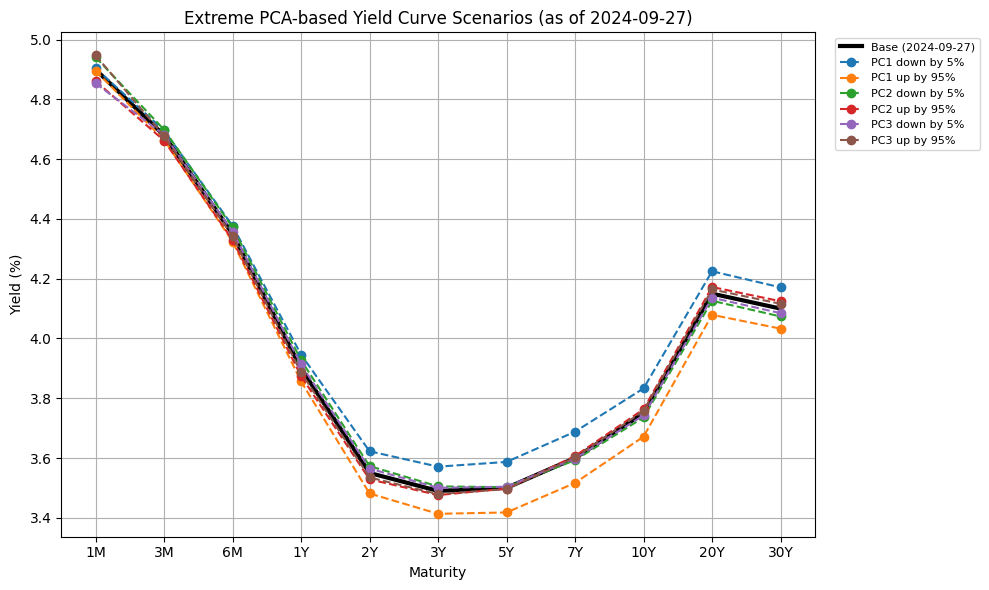

In [81]:
#  Latest curve (Sep 27, 2024)
base_curve = yieldcurve.loc["2024-09-27", cols].values   # yields in %

# Build shocked curves (we already created scenarios in bp above)
shocked_curves = {name: base_curve + (shock/100.0) for name, shock in scenarios.items()}

# Plot
plt.figure(figsize=(10,6))
plt.plot(maturity_labels, base_curve, color="black", linewidth=3, label="Base (2024-09-27)")

for name, curve in shocked_curves.items():
    plt.plot(maturity_labels, curve, marker="o", linestyle="--", label=name)

plt.title("Extreme PCA-based Yield Curve Scenarios (as of 2024-09-27)")
plt.xlabel("Maturity")
plt.ylabel("Yield (%)")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

<font color="blue"><b>Ex. 10 (m)</b></font>

Both PCA and PAF extract the same underlying yield curve dynamics: Level, Slope, and Curvature, but they differ in focus. **PCA** explains the total variance (common plus idiosyncratic noise), while **PAF** explains only the common variance shared across maturities, filtering out noise; as a result, the shapes of the factors are nearly identical, but PAF gives slightly different magnitudes, making PCA more useful for statistical compression and hedging, and PAF better suited for interpreting underlying economic drivers.

In [82]:
# Correlation matrix of yield changes
corr = yieldcurve_pct[cols].corr()

# PCA (eigendecomp)
eigvals, eigvecs = np.linalg.eigh(corr)
idx = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
pca_loadings = eigvecs[:, :3] * np.sqrt(eigvals[:3])

# PAF (principal axis factoring) on raw yield changes
fa = FactorAnalyzer(n_factors=3, rotation=None, method="principal")
fa.fit(yieldcurve_pct[cols].dropna())   # pass data, not corr matrix
paf_loadings = fa.loadings_

# Results
print("PCA loadings (first 3):\n",
      pd.DataFrame(pca_loadings, index=maturity_labels).round(3))
print("\nPAF loadings (first 3):\n",
      pd.DataFrame(paf_loadings, index=maturity_labels).round(3))

PCA loadings (first 3):
          0      1      2
1M  -0.014 -0.539  0.239
3M  -0.104 -0.757  0.149
6M  -0.147 -0.787  0.060
1Y  -0.469 -0.344 -0.616
2Y  -0.753 -0.035 -0.408
3Y  -0.892  0.014 -0.217
5Y  -0.954  0.067 -0.053
7Y  -0.975  0.091  0.075
10Y -0.963  0.088  0.189
20Y -0.922  0.081  0.291
30Y -0.894  0.072  0.322

PAF loadings (first 3):
          0      1      2
1M   0.014  0.539  0.239
3M   0.104  0.757  0.149
6M   0.147  0.787  0.060
1Y   0.469  0.344 -0.616
2Y   0.753  0.035 -0.408
3Y   0.892 -0.014 -0.217
5Y   0.954 -0.067 -0.053
7Y   0.975 -0.091  0.075
10Y  0.963 -0.088  0.189
20Y  0.922 -0.081  0.291
30Y  0.894 -0.072  0.322


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<font color="blue"><b>Ex. 11 (a)</b></font>

A copula function is a multivariate uniform distribution over the $[0, 1]$ hypercube. For a bivariate function $C(u, v) : [0, 1] \times [0, 1] \to [0, 1]$, we call $C(u, v)$ a bivariate copula function if it meets the following three conditions:

a. $C(0, u) = C(u, 0) = 0$  

b. $C(1, u) = C(u, 1) = u$  

c. $C(u_2, v_2) - C(u_2, v_1) - C(u_1, v_2) + C(u_1, v_1) \geq 0$  
   for all $0 \leq u_1 \leq u_2 \leq 1$ and $0 \leq v_1 \leq v_2 \leq 1$      
We want to show that $F(X)$, as a function of the random variable $X$, is a uniform distribution.   
Since $F(x)$ is strictly increasing and continuous, it has an inverse $F^{-1}$. For any $u \in (0,1)$:
$$\mathbb{P}(F(X) \le u)
= \mathbb{P}\big(X \le F^{-1}(u)\big)
= F\!\big(F^{-1}(u)\big)
= u$$
Thus, the distribution function of $F(X)$ is $H(u) = u$ on $[0,1]$, which is exactly the CDF of $\mathrm{Unif}(0,1)$.  
Therefore,
$$F(X) \sim \mathrm{Unif}(0,1)$$

<font color="blue"><b>Ex. 11 (b)</b></font>

We define
$$F(x_1, x_2) = C(F_1(x_1), F_2(x_2)),$$
where $F_1$ and $F_2$ are univariate CDFs, and $C$ is a copula.  
- Since $F_1(x_1) \in [0,1]$ and $F_2(x_2) \in [0,1]$, the input to $C$ is always inside $[0,1]^2$.  
A copula $C$ satisfies:
  1. **Groundedness:** $C(u,0) = C(0,v) = 0$.  
  2. **Margins:** $C(u,1) = u$, $C(1,v) = v$.  
  3. **2-increasing property:** For any rectangle $[u_1,u_2]\times[v_1,v_2] \subset [0,1]^2$,
  $$V_C = C(u_2,v_2) - C(u_2,v_1) - C(u_1,v_2) + C(u_1,v_1) \ge 0$$
- By composition, $F(x_1,x_2)$ inherits these properties and is a valid **bivariate CDF**.    
The marginal of $X_1$ is defined as:
$$F_{X_1}(x_1) = \lim_{x_2 \to \infty} F(x_1,x_2)$$
$$F_{X_1}(x_1) = \lim_{x_2 \to \infty} C(F_1(x_1), F_2(x_2))$$
Since $\lim_{x_2 \to \infty} F_2(x_2) = 1$, this becomes:
$$F_{X_1}(x_1) = C(F_1(x_1), 1)$$
By the copula property $C(u,1) = u$, we get:
$$F_{X_1}(x_1) = F_1(x_1)$$
Similarly,
$$F_{X_2}(x_2) = \lim_{x_1 \to \infty} F(x_1,x_2)$$
Compute explicitly:
$$F_{X_2}(x_2) = \lim_{x_1 \to \infty} C(F_1(x_1), F_2(x_2))$$
Since $\lim_{x_1 \to \infty} F_1(x_1) = 1$, this becomes:
$$F_{X_2}(x_2) = C(1, F_2(x_2))$$
By the copula property $C(1,v) = v$, we get:
$$F_{X_2}(x_2) = F_2(x_2)$$
- $F(x_1, x_2) = C(F_1(x_1), F_2(x_2))$ is a valid **bivariate distribution** (if $C$ is a copula).  
- Its **marginals** are exactly:
$$F_{X_1}(x_1) = F_1(x_1), \quad F_{X_2}(x_2) = F_2(x_2)$$

<font color="blue"><b>Ex. 11 (c)</b></font>

We verify the three copula properties.  
**Boundary conditions:**  
$$C(0,u) = \min(0,u) = 0, \quad C(u,0) = \min(u,0) = 0$$
and  
$$C(1,u) = \min(1,u) = u, \quad C(u,1) = \min(u,1) = u$$
**2-increasing property:** For any $0 \le u_1 \le u_2 \le 1$ and $0 \le v_1 \le v_2 \le 1$,  
$$\Delta = C(u_2,v_2) - C(u_2,v_1) - C(u_1,v_2) + C(u_1,v_1)$$
There are three possible cases:  
- If $u_2 \le v_1$, then all terms equal the corresponding $u$’s, and $\Delta = 0$.  
- If $v_2 \le u_1$, then all terms equal the $v$’s, and again $\Delta = 0$.  
- If $u_1 < v_1 < u_2 < v_2$, then the combination always yields $\Delta = 0$.  

Thus, $\Delta \ge 0$ in all cases.  
Hence $C(u,v) = \min(u,v)$ satisfies all copula properties.

<font color="blue"><b>Ex. 11 (d)</b></font>

We want to show that for any copula $C(u,v)$,
$$\max(u+v-1,0) \leq C(u,v) \leq \min(u,v)$$
Let
$$A = \{X_1 \le x_1\}, \quad B = \{X_2 \le x_2\}$$
By definition of the copula,
$$C(u,v) = \Pr(U \le u, V \le v) = \Pr(A \cap B),$$
where
$$u = \Pr(A) = F_1(x_1), \quad v = \Pr(B) = F_2(x_2)$$
For any two events $A$ and $B$,
$$\Pr(A) + \Pr(B) - 1 \;\leq\; \Pr(A \cap B) \;\leq\; \min(\Pr(A), \Pr(B))$$
Substituting $\Pr(A) = u$ and $\Pr(B) = v$ gives
$$u + v - 1 \;\leq\; C(u,v) \;\leq\; \min(u,v)$$
Since probabilities cannot be negative,
$$\Pr(A \cap B) \ge 0$$
Thus the actual lower bound is the maximum between $0$ and $u+v-1$:
$$\max(u+v-1, 0) \;\leq\; C(u,v) \;\leq\; \min(u,v)$$
For any bivariate copula function $C(u,v)$,
$$\max(u+v-1, 0) \;\leq\; C(u,v) \;\leq\; \min(u,v).$$


<font color="blue"><b>Ex. 12</b></font>

For any bivariate normal random vector $(X,Y)$ and any function $h(x)$, prove that  
$$\mathbb{E}[h(X)e^{-Y}] = \mathbb{E}[e^{-Y}] \, \mathbb{E}[h(X - \mathrm{Cov}(X,Y))]$$
Let $(X,Y)$ be jointly Gaussian with mean vector $\mu=(\mu_X,\mu_Y)$ and covariance matrix  
$$\Sigma =
\begin{pmatrix}
\mathrm{Var}(X) & \mathrm{Cov}(X,Y) \\
\mathrm{Cov}(X,Y) & \mathrm{Var}(Y)
\end{pmatrix}$$
For any $t\in\mathbb{R}$, define the tilted expectation  
$$\mathbb{E}_t[\cdot] = \frac{\mathbb{E}[(\cdot)e^{tY}]}{\mathbb{E}[e^{tY}]}$$
Under $\mathbb{E}_t$, the distribution of $(X,Y)$ remains Gaussian with **shifted mean**  
$$\mu_t = \mu + t\,\Sigma e_2,$$
where $e_2=(0,1)^\top$. Explicitly,  
$$\mathbb{E}_t[X] = \mu_X + t \,\mathrm{Cov}(X,Y), \qquad
\mathbb{E}_t[Y] = \mu_Y + t \,\mathrm{Var}(Y)$$
The covariance matrix is unchanged.   
Therefore, under $\mathbb{E}_t$, the marginal of $X$ is the same as the original $X$ shifted by $t\,\mathrm{Cov}(X,Y)$. Hence for any function $h$:
$$\mathbb{E}_t[h(X)] = \mathbb{E}[h(X + t\,\mathrm{Cov}(X,Y))]$$
By definition,
$$\mathbb{E}[h(X)e^{tY}] = \mathbb{E}[e^{tY}] \, \mathbb{E}_t[h(X)]
= \mathbb{E}[e^{tY}] \, \mathbb{E}[h(X + t\,\mathrm{Cov}(X,Y))]$$
Set $t=-1$  
Finally, substitute $t=-1$:
$$\mathbb{E}[h(X)e^{-Y}]
= \mathbb{E}[e^{-Y}] \, \mathbb{E}[h(X - \mathrm{Cov}(X,Y))]$$
The identity holds for any integrable function $h$, completing the proof.


<font color="blue"><b>Ex. 13 (a)</b></font>

Suppose we have two random variables $X_1$ and $X_2$, and we define  
$X_{1,2} = \min(X_1,X_2)$ and $X_{2,2} = \max(X_1,X_2)$.

Let $F_1(x) = \mathbb{P}(X_1 \le x)$ and $F_2(x) = \mathbb{P}(X_2 \le x)$.  
If $X_1$ and $X_2$ are independent:
- Minimum:
$$F_{1,2}(x) = \mathbb{P}(X_{1,2} \le x)
= 1 - \mathbb{P}(X_1 > x, X_2 > x)
= 1 - (1-F_1(x))(1-F_2(x))$$
- Maximum:
$$F_{2,2}(x) = \mathbb{P}(X_{2,2} \le x)
= \mathbb{P}(X_1 \le x, X_2 \le x)
= F_1(x)F_2(x)$$

<font color="blue"><b>Ex. 13 (b)</b></font>

Survival of the minimum:
$$S_{1,2}(x)=\mathbb{P}(X_{1,2}>x)=S_1(x)S_2(x)$$
Differentiate $F_{1,2}(x)=1-S_{1,2}(x)$:
$$f_{1,2}(x)=f_1(x)S_2(x)+f_2(x)S_1(x)$$
Therefore the hazard
$$h_{1,2}(x)=\frac{f_{1,2}(x)}{S_{1,2}(x)}
=\frac{f_1(x)}{S_1(x)}+\frac{f_2(x)}{S_2(x)}
=h_1(x)+h_2(x)$$

<font color="blue"><b>Ex. 13 (c)</b></font>

Prove that for any two random variables $X_1$ and $X_2$ (not necessarily independent),
$$F_{1,2}(x) + F_{2,2}(x) = F_1(x) + F_2(x),$$
where $X_{1,2} = \min(X_1, X_2)$ and $X_{2,2} = \max(X_1, X_2)$.

Define the events:
$$A = \{X_1 \le x\}, \qquad B = \{X_2 \le x\}$$
- The minimum satisfies
$$\{X_{1,2} \le x\} = \{\min(X_1,X_2) \le x\} = A \cup B,$$
so
$$F_{1,2}(x) = \mathbb{P}(X_{1,2} \le x) = \mathbb{P}(A \cup B)$$
- The maximum satisfies
$$\{X_{2,2} \le x\} = \{\max(X_1,X_2) \le x\} = A \cap B,$$
so
$$F_{2,2}(x) = \mathbb{P}(X_{2,2} \le x) = \mathbb{P}(A \cap B)$$

Adding,
$$F_{1,2}(x) + F_{2,2}(x) = \mathbb{P}(A \cup B) + \mathbb{P}(A \cap B)$$

By the probability identity
$$\mathbb{P}(A \cup B) + \mathbb{P}(A \cap B) = \mathbb{P}(A) + \mathbb{P}(B),$$
we obtain
$$F_{1,2}(x) + F_{2,2}(x) = \mathbb{P}(A) + \mathbb{P}(B) = F_1(x) + F_2(x)$$
The equality
$$F_{1,2}(x) + F_{2,2}(x) = F_1(x) + F_2(x)$$
holds for all $x$, without assuming independence between $X_1$ and $X_2$.


In [ ]:
!apt-get install -y texlive-xetex texlive-fonts-recommended texlive-latex-extra


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-recommended texlive-pictures texlive-plain-generic tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf libavalon-framework-java
  libcommons-logging-java-doc libexcalibur-logkit-jav

In [ ]:
!jupyter nbconvert --to pdf "/content/your_notebook_name.ipynb"